# E72 · Topic models beyond text: LDA for headlines, and for the colours of posters

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) the **Upworthy Research Archive** (Matias et al. 2021, *Scientific Data*): 4,873 headline A/B tests, 2013-2015, with impressions and clicks; (2) **750 public-domain posters from the Library of Congress** in three eras of printed "creatives" - 1890s magazine and book posters, First World War posters, and WPA posters (1936-1943) - as 64 x 48 thumbnails |
| **You will learn** | **Latent Dirichlet allocation** (LDA) as a mixed-membership model for *any* bag of discrete features · marginalising the token-level topic labels so NUTS can fit it in PyMC · **label switching** across chains and aligning topics with the Hungarian algorithm · why NUTS struggles on a large sparse vocabulary and how a **collapsed Gibbs sampler** (Numba) does the text · topic **stability** across restarts · why held-out likelihood keeps asking for more topics, and choosing the number of topics by what they are *for* · using topic proportions as regressors (click-through rates), and why pooling regressions over posterior draws of the mixtures **biases** the effects - checked by simulation · turning images into documents: a **colour vocabulary** in CIELab and pixels as tokens · removing what the scanner adds · palette topics from Gibbs restarts, and paper as a pictorial stopword · topic mixtures that depend on covariates: **logistic normal** (structural topic model) vs **Dirichlet-multinomial regression**, sampled as normalised log-Gammas · a semi-supervised model that dates hidden posters, and checking its calibration · how many independent tokens a picture is worth · **displaying topics so readers understand them**: relevance-ranked terms (LDAvis), an intertopic map that shows chain-to-chain stability, words highlighted by topic inside headlines, prevalence over time with bands, palettes on a lightness-hue map, posters segmented pixel by pixel into palettes with a colour check, a thumbnail atlas of the collection, and era compositions painted in their own palettes |

## The setting

A **topic model** describes a collection of documents as mixtures of a few recurring themes.
Latent Dirichlet allocation (Blei, Ng & Jordan 2003) says:

* there are $K$ **topics**; topic $k$ is a probability distribution $\phi_k$ over a vocabulary of
  $V$ words;
* each **document** $d$ has its own mixture $\theta_d$ over the topics;
* each **token** in document $d$ is made by first drawing a topic $z \sim \theta_d$ and then a
  word $w \sim \phi_z$.

Nothing in this story needs the "words" to be words. All LDA sees is a table of counts: *how
often did feature $w$ occur in unit $d$*. Any data of that shape can be read as documents made of
a few mixed "themes":

| domain | document | "word" | a topic is... |
|---|---|---|---|
| text | article, headline set | word | a theme |
| **images, creatives, magazine covers** | **an image** | **a quantised colour (or visual word)** | **a palette** |
| retail | a shopping basket or customer | product | a shopping mission |
| population genetics | a person's genome | allele at a locus | an ancestral population (the STRUCTURE model of Pritchard, Stephens & Donnelly 2000 *is* LDA) |
| microbiome | a sample | bacterial taxon | a community type |
| web analytics | a user session | page or event | a browsing intent |
| music | a playlist | track or chord | a style |

This notebook fits LDA to two such collections and, in each case, *uses* the topics for something:

| part | question | tool |
|---|---|---|
| A | What is LDA, and can PyMC fit it? | marginalised likelihood, simulated check, label switching |
| B | What are Upworthy's stories about? | collapsed Gibbs sampler, stability across restarts; four displays of word topics |
| C | How many topics, and do topics predict clicks? | held-out likelihood vs downstream prediction, regression with uncertain regressors |
| D | How do you turn a poster into a document? | CIELab colour vocabulary, pixels as tokens |
| E | Which palettes recur across 750 posters? | Gibbs restarts, palette stability; four displays of palettes |
| F | How did palettes change from the 1890s to the WPA, and when was this poster made? | logistic-normal vs Dirichlet era models, semi-supervised dating, calibration |
| G | How much is a picture worth? | the number of tokens per image and what it does to certainty |

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import re
from collections import Counter
from scipy.optimize import linear_sum_assignment

from pymc_challenges import data

RANDOM_SEED = 72
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)

## A. The model, and a check on simulated data

Written out for one document with counts $n_{dw}$ (how often word $w$ appears in document $d$),
the token-level topic labels $z$ can be **summed out**: a token is word $w$ with probability

$$p_{dw} = \sum_{k=1}^K \theta_{dk}\,\phi_{kw}, \qquad \text{so} \qquad
\mathbf n_d \sim \text{Multinomial}\big(N_d,\; \boldsymbol\theta_d^\top \Phi\big).$$

That is a plain multinomial with a low-rank probability matrix $\Theta\Phi$ ($D \times V$, rank
$K$): LDA is a *non-negative matrix factorisation of the count table with a multinomial
likelihood and Dirichlet priors*. With $z$ gone every parameter is continuous, so NUTS can run.
The priors are

$$\boldsymbol\theta_d \sim \text{Dirichlet}(\alpha\mathbf 1_K), \qquad
\boldsymbol\phi_k \sim \text{Dirichlet}(\beta\mathbf 1_V),$$

with $\alpha < 1$ saying "a document is mostly about a few topics" and $\beta < 1$ saying "a
topic uses a small part of the vocabulary".

Before any real data, check the machinery on a corpus where we know the answer: 200 documents
of 60 tokens over a 24-word vocabulary, made from 3 topics.

In [2]:
D_sim, V_sim, K_sim, N_sim = 200, 24, 3, 60
phi_true = rng.dirichlet(np.full(V_sim, 0.3), K_sim)
theta_true = rng.dirichlet(np.full(K_sim, 0.5), D_sim)
X_sim = np.array([rng.multinomial(N_sim, theta_true[d] @ phi_true) for d in range(D_sim)])

with pm.Model(coords={"doc": range(D_sim), "topic": range(K_sim), "word": range(V_sim)}) as lda_sim:
    theta = pm.Dirichlet("theta", a=np.full(K_sim, 0.5), dims=("doc", "topic"))
    phi = pm.Dirichlet("phi", a=np.full(V_sim, 0.5), dims=("topic", "word"))
    pm.Multinomial("x", n=N_sim, p=theta @ phi, observed=X_sim, dims=("doc", "word"))
    idata_sim = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

print("divergences:", int(idata_sim.sample_stats["diverging"].sum()))
print("largest r_hat of phi, as sampled:", round(float(az.rhat(idata_sim.posterior["phi"]).max()), 2))

divergences: 0
largest r_hat of phi, as sampled: 1.75


Zero divergences, yet $\hat R$ is far above 1. The reason is not a sampling failure: the
likelihood is unchanged if the topics are relabelled, so "topic 0" in one chain can be "topic 2"
in another. This is **label switching**, and every mixture and topic model has it. NUTS rarely
switches labels *within* a chain (the modes are far apart), so the fix is to match topics
*across* chains: compute a cost for pairing topic $j$ of one chain with topic $k$ of a reference
chain (here the squared distance between their word distributions) and solve the assignment
problem (`scipy.optimize.linear_sum_assignment`, the Hungarian algorithm).

topic permutation per chain:
 [[0 1 2]
 [0 1 2]
 [1 2 0]
 [1 2 0]]
largest r_hat of phi after alignment: 1.008


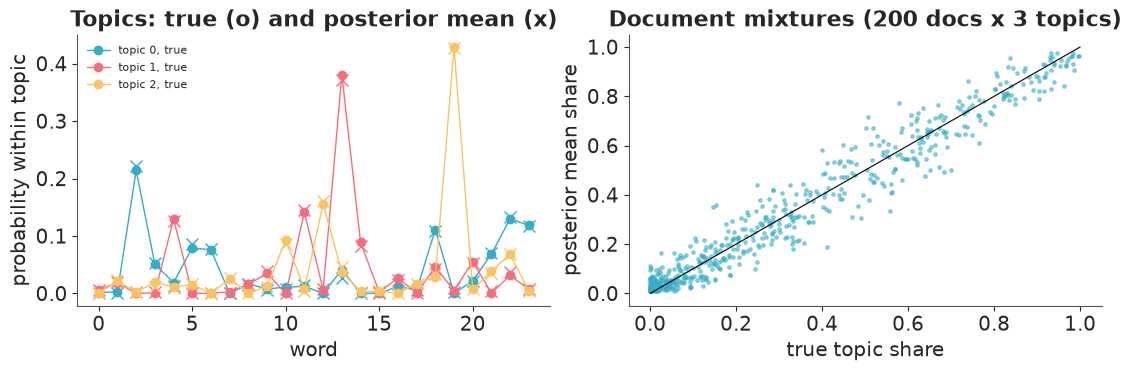

In [3]:
def align_to(ref, other):
    """Permutation `perm` such that other[perm] best matches ref (rows are topics)."""
    cost = ((ref[:, None, :] - other[None, :, :]) ** 2).sum(-1)
    return linear_sum_assignment(cost)[1]


def align_chains(phi_draws):
    """phi_draws: (chain, draw, topic, word). Returns one permutation per chain (chain 0 = reference)."""
    means = phi_draws.mean(1)
    return np.array([align_to(means[0], means[c]) for c in range(len(means))])


phi_s = idata_sim.posterior["phi"].values
perms_sim = align_chains(phi_s)
print("topic permutation per chain:\n", perms_sim)
phi_aligned = np.stack([phi_s[c][:, perms_sim[c]] for c in range(phi_s.shape[0])])
theta_s = idata_sim.posterior["theta"].values
theta_aligned = np.stack([theta_s[c][:, :, perms_sim[c]] for c in range(theta_s.shape[0])])
rhat_aligned = az.rhat(np.asarray(phi_aligned).reshape(phi_aligned.shape[0], phi_aligned.shape[1], -1))
print("largest r_hat of phi after alignment:", round(float(np.max(rhat_aligned)), 3))

# match the fitted topics to the true ones for the plot
to_true = align_to(phi_true, phi_aligned.mean((0, 1)))
phi_fit = phi_aligned.mean((0, 1))[to_true]
theta_fit = theta_aligned.mean((0, 1))[:, to_true]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for k in range(K_sim):
    axes[0].plot(phi_true[k], "o-", color=f"C{k}", lw=1, label=f"topic {k}, true")
    axes[0].plot(phi_fit[k], "x", color=f"C{k}", ms=8)
axes[0].set(xlabel="word", ylabel="probability within topic", title="Topics: true (o) and posterior mean (x)")
axes[0].legend(fontsize=8)
axes[1].scatter(theta_true.ravel(), theta_fit.ravel(), s=6, alpha=0.5)
axes[1].plot([0, 1], [0, 1], color="k", lw=0.8)
axes[1].set(xlabel="true topic share", ylabel="posterior mean share", title="Document mixtures (200 docs x 3 topics)");

After alignment the chains agree, and both the topics and the per-document mixtures are
recovered. Two things to remember for the real data:

* **Always align before diagnosing.** Raw $\hat R$ on topics measures the arbitrary labelling.
* **Alignment only fixes permutations.** Real corpora also have *genuinely different* local
  solutions - two chains that split the same material into topics differently. No permutation
  fixes that, and we will meet it in the text.

## B. What are Upworthy's stories about?

Upworthy (2013-2015) tested several headlines for every story it published and showed each
visitor one of them at random. The archive has 4,873 tests from its exploratory sample (E66 used
it for A/B testing). A **document** here is one test: all the distinct headlines written for one
story, pooled. That makes the topics about *stories*, not about the wording of one headline.

Preparing text for LDA is a bag-of-words recipe: lower-case, split into words, drop "stopwords"
(*the*, *you*, *this*, which every topic would otherwise share), fold plurals onto singulars
when both are common, and keep words that appear in at least 20 tests but in no more than 10% of
them (rare words cannot be learned; ubiquitous ones say nothing).

In [4]:
data.describe("upworthy_exploratory")
uw = data.load("upworthy_exploratory")

STOP = set("""a about above after again against all am an and any are aren't as at be because been before
being below between both but by can can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's
hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me
more most mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same
shan't she she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves
then there there's these they they'd they'll they're they've this those through to too under until up very
was wasn't we we'd we'll we're we've were weren't what what's when when's where where's which while who who's
whom why why's with won't would wouldn't you you'd you'll you're you've your yours yourself yourselves just
like get gets got one two really thing things way ever even also make makes made know see go going goes say
says said will new something every much many want wants yes""".split())


def tokens(headline):
    words = re.findall(r"[a-z][a-z']+", headline.lower().replace("’", "'"))
    return [w for w in words if w not in STOP and len(w) > 2]


heads = uw.drop_duplicates(["test_id", "headline"])
docs = heads.groupby("test_id")["headline"].apply(lambda h: sum((tokens(x) for x in h), []))
doc_freq = Counter(w for d in docs for w in set(d))
fold = {w: w[:-1] for w in doc_freq if w.endswith("s") and doc_freq.get(w[:-1], 0) >= 20}
docs = docs.map(lambda d: [fold.get(w, w) for w in d])
doc_freq = Counter(w for d in docs for w in set(d))
vocab = np.array(sorted(w for w, c in doc_freq.items() if 20 <= c <= 0.1 * len(docs)))
w_index = {w: i for i, w in enumerate(vocab)}
X_all = np.zeros((len(docs), len(vocab)), dtype=np.int64)
for d, ws in enumerate(docs):
    for w in ws:
        if w in w_index:
            X_all[d, w_index[w]] += 1
keep = X_all.sum(1) >= 3
X_txt, test_ids = X_all[keep], docs.index.to_numpy()[keep]
print(f"{len(docs)} tests, vocabulary of {len(vocab)} words; {keep.sum()} tests keep >= 3 tokens")
print(f"tokens per test: median {np.median(X_txt.sum(1)):.0f}, total {X_txt.sum():,}")
print("most common kept words:", ", ".join(vocab[np.argsort(-X_txt.sum(0))[:25]]))

upworthy_exploratory: Exploratory sample of Upworthy's headline A/B tests, Jan 2013 - Apr 2015: 4,873 tests, 22,666 packages (arms; 2-14 per test, mostly 4-6), one row per package: test_id (clickability_test_id), test_created (date of the test's first package), test_week (YYYYWW), arm (0.. within test, by creation time), content_id (arms of one test with the same id are identical in headline, image, excerpt, lede, share text and square image: natural A/A arms), headline, eyecatcher_id (image), impressions, clicks, significance (Upworthy's dashboard number), first_place, winner (editor's declared winner).
  source: Matias, Munger, Aubin Le Quere & Ebersole (2021), The Upworthy Research Archive, a time series of 32,487 experiments in U.S. media, Scientific Data 8:195 (doi:10.1038/s41597-021-00934-7); OSF project jd64p (CC BY 4.0), file upworthy-archive-exploratory-packages-03.12.2020.csv (the URL). TRIMMED: kept the columns below, dropped excerpt/lede/share text/image URL/slug, added arm

Documents are *short*: a median of about a dozen kept tokens. That is typical of headlines,
tweets, search queries, product titles and survey answers, and it matters: each document says
little about its own mixture, so topics must be learned from co-occurrence across thousands of
documents.

### NUTS does not scale here - a collapsed Gibbs sampler does

The PyMC model of part A has $D(K-1) + K(V-1)$ continuous parameters: about 30,000 for this
corpus with $K = 6$. While preparing this notebook, we ran it on a random 800 of these tests with
$K = 6$, $\alpha = 0.5$, $\beta = 0.1$: it took **6 minutes**, gave **517 divergences**, hit the
maximum tree depth in three quarters of the transitions, and the four chains found four
different sets of topics. Sparse Dirichlet priors over hundreds of words put mass in corners
that NUTS cannot reach smoothly (AUTHORING notes the same for sparse Dirichlet mixtures).

The standard tool for LDA is the **collapsed Gibbs sampler** (Griffiths & Steyvers 2004). It
does the opposite of part A: it keeps the discrete $z$ and integrates out $\theta$ and $\phi$
(Dirichlet-multinomial conjugacy). Each token's topic is then resampled from

$$P(z_i = k \mid \mathbf z_{-i}) \;\propto\; (n_{dk}^{-i} + \alpha)\,
\frac{n_{kw}^{-i} + \beta}{n_k^{-i} + V\beta},$$

where the $n$ are counts of tokens assigned to topic $k$ in document $d$, of word $w$ in topic
$k$, and in topic $k$ overall, all excluding token $i$. One sweep over the 50,000 tokens takes
milliseconds in Numba. Posterior draws of $\phi$ and $\theta$ come from their Dirichlet full
conditionals given the counts at saved sweeps.

In [5]:
@numba.njit
def _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, n_sweeps, seed):
    np.random.seed(seed)
    K, V = nkw.shape
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1
            nkw[k, w] -= 1
            nk[k] -= 1
            total = 0.0
            for j in range(K):
                total += (ndk[d, j] + alpha) * (nkw[j, w] + beta) / (nk[j] + V * beta)
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k
            ndk[d, k] += 1
            nkw[k, w] += 1
            nk[k] += 1


def lda_gibbs(X, K, alpha=0.1, beta=0.05, burn=2000, draws=40, thin=10, seed=0):
    """Collapsed Gibbs LDA on a document x word count matrix.

    Returns posterior draws of phi (draw, topic, word) and theta (draw, doc, topic), and the
    log-likelihood of the tokens at each saved sweep.
    """
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X)
    n = X[d_i, w_i]
    doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    z = g.integers(K, size=doc.size)
    D, V = X.shape
    ndk, nkw = np.zeros((D, K), np.int64), np.zeros((K, V), np.int64)
    np.add.at(ndk, (doc, z), 1)
    np.add.at(nkw, (z, word), 1)
    nk = nkw.sum(1)
    _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, burn, seed)
    phis, thetas, lls = [], [], []
    for s in range(draws):
        _gibbs_sweeps(doc, word, z, ndk, nkw, nk, alpha, beta, thin, seed + 1 + s)
        phi_s = g.gamma(nkw + beta)
        theta_s = g.gamma(ndk + alpha)
        phis.append(phi_s / phi_s.sum(1, keepdims=True))
        thetas.append(theta_s / theta_s.sum(1, keepdims=True))
        lls.append(np.sum(X * np.log(thetas[-1] @ phis[-1])))
    return np.array(phis), np.array(thetas), np.array(lls)


K_TXT = 6
t0 = time.perf_counter()
fits = [lda_gibbs(X_txt, K_TXT, seed=c) for c in range(4)]
print(f"4 chains x 2,400 sweeps: {time.perf_counter() - t0:.1f} s (includes Numba compilation)")
phi_txt = np.stack([f[0] for f in fits])       # chain, draw, topic, word
theta_txt = np.stack([f[1] for f in fits])     # chain, draw, doc, topic
ll_txt = np.stack([f[2] for f in fits])
print("token log-likelihood per chain (mean over saved sweeps):", np.round(ll_txt.mean(1)))

4 chains x 2,400 sweeps: 11.5 s (includes Numba compilation)
token log-likelihood per chain (mean over saved sweeps): [-302356. -301794. -302354. -301947.]


Align the chains as in part A, then ask a question alignment cannot answer by itself: **is each
topic the same topic in every chain?** For each topic of the reference chain we report the
cosine similarity of its word distribution to its match in each other chain (1 = identical).

In [6]:
perms_txt = align_chains(phi_txt)
phi_txt = np.stack([phi_txt[c][:, perms_txt[c]] for c in range(4)])
theta_txt = np.stack([theta_txt[c][..., perms_txt[c]] for c in range(4)])
phi_mean_c = phi_txt.mean(1)                    # chain, topic, word


def cosine(a, b):
    return np.sum(a * b, -1) / np.linalg.norm(a, axis=-1) / np.linalg.norm(b, axis=-1)


stability = np.array([cosine(phi_mean_c[0], phi_mean_c[c]) for c in range(1, 4)]).T
labels_txt = [" / ".join(vocab[np.argsort(-phi_mean_c[0, k])[:3]]) for k in range(K_TXT)]
stab = pd.DataFrame(stability.round(2), index=labels_txt, columns=["chain 1", "chain 2", "chain 3"])
stab["min"] = stab.min(axis=1)
print(stab)

                        chain 1  chain 2  chain 3   min
world / video / change     0.73     0.79     0.75  0.73
kid / school / parent      0.80     0.81     0.81  0.80
year / girl / old          0.45     0.81     0.47  0.45
never / video / minute     0.65     0.78     0.66  0.65
state / reason / time      0.84     0.25     0.76  0.25
women / guy / men          0.89     0.88     0.84  0.84


The table is the honest summary of an LDA fit on short texts: **some topics come back in every
chain and some do not**. "women / guy / men" (at least 0.84) and "kid / school / parent" (0.80)
are found by every chain; "state / reason / time" has only a loose match (0.25) in one chain and
"year / girl / old" (0.45) in two. A stable
topic is a real pattern in the co-occurrence of words; an unstable one is one of several equally
good ways to cut up the rest. When LDA topics are reported without this check, readers cannot
tell which kind they are looking at.

The top words below are from the reference chain, with the posterior uncertainty of each
word's probability (a 90% interval over saved sweeps) - the sampling uncertainty is small
compared with the chain-to-chain differences above.

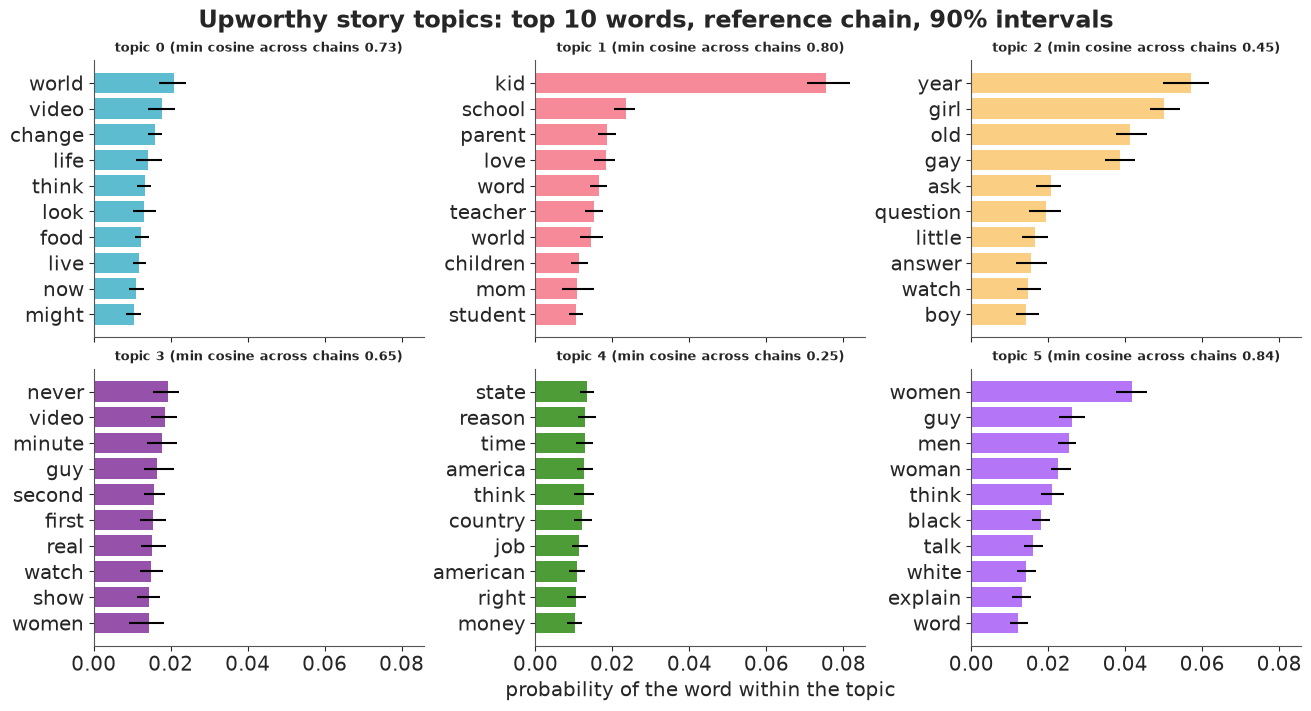

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for k, ax in enumerate(axes.ravel()):
    top = np.argsort(-phi_mean_c[0, k])[:10][::-1]
    lo, hi = np.quantile(phi_txt[0][:, k, top], [0.05, 0.95], axis=0)
    ax.barh(range(10), phi_mean_c[0, k, top], xerr=[phi_mean_c[0, k, top] - lo, hi - phi_mean_c[0, k, top]],
            color=f"C{k}", alpha=0.8)
    ax.set_yticks(range(10), vocab[top])
    ax.set_title(f"topic {k} (min cosine across chains {stab['min'].iloc[k]:.2f})", fontsize=9)
axes[1, 1].set_xlabel("probability of the word within the topic")
fig.suptitle("Upworthy story topics: top 10 words, reference chain, 90% intervals");

A few example stories for each topic: the tests with the largest posterior mean share of it,
shown by their first headline.

In [8]:
first_headline = uw.sort_values("arm").groupby("test_id")["headline"].first()
theta_ref = theta_txt[0].mean(0)
for k in range(K_TXT):
    print(f"\ntopic {k}: {labels_txt[k]}")
    for d in np.argsort(-theta_ref[:, k])[:3]:
        print(f"   {theta_ref[d, k]:.2f}  {first_headline[test_ids[d]][:110]}")


topic 0: world / video / change
   0.97  The Cost Of Being A Trendy Eater Hurts A Lot More People Than The Whole Foods Crowd May Realize
   0.97  Watch This Ridiculously Adorable And Uplifting Video Of A Huge Company Actually Doing Good Stuff
   0.97  File This Under Awesome Things About The Universe That I Had No Clue About

topic 1: kid / school / parent
   0.98  Oscar Winner Lupita Nyong’o's Speech On Beauty That Left An Entire Audience Speechless
   0.97  Instead Of Saying She Was 'Born A Boy' Try Saying It Her Way Instead. It Just Rings More True.
   0.97  A Teacher Tells A Story About A Boy In Her Class. It Desperately Needs A Happy Ending.

topic 2: year / girl / old
   0.99  Pink, Ellen, Katy Perry, And A Hockey Player Walk Into A Commercial And Destroy A Silly Argument
   0.98  A 4-Year-Old Girl Asked A Lesbian If She Was A Boy. She Responded The Awesomest Way Possible.
   0.97  A Little Girl Uses A Metaphor To Get You To Think About What Stops Girls From Getting Into Science

### Better ways to look at word topics

A list of top words per topic is the most common display of a topic model, and one of the least
informative. It hides four things a reader needs: which words are *specific* to a topic rather
than merely frequent everywhere, how the topics relate to each other (and how stable they are),
what a topic looks like inside a real document, and how much of the corpus each topic is,
over time. Four displays, one for each. Every figure uses the same colour for the same topic
(a categorical palette checked for colour-vision deficiency; every coloured mark also carries a
text label).

**1. Relevance, not probability** (Sievert & Shirley 2014, the "LDAvis" display). Ranking by
$\phi_{kw}$ puts corpus-wide words ("video", "think", "time") at the top of several topics. The
*relevance* of word $w$ to topic $k$ blends its probability with its **lift**, how much more
common it is in the topic than in the corpus:

$$r_{kw}(\lambda) = \lambda \log \phi_{kw} + (1 - \lambda) \log \frac{\phi_{kw}}{p_w},$$

with $\lambda = 0.6$, the value their user study found most helpful. Each bar pair then shows
the word's estimated count *in the topic* (coloured) against its count in *all* tests (grey): a
coloured bar that fills its grey bar is a word that belongs to that topic alone.

top-3 words by probability vs by relevance:
                    probability                relevance
topic 0  world / video / change    change / world / food
topic 1   kid / school / parent    kid / school / parent
topic 2       year / girl / old        year / girl / old
topic 3  never / video / minute  second / never / minute
topic 4   state / reason / time   state / country / wage
topic 5       women / guy / men      women / men / black


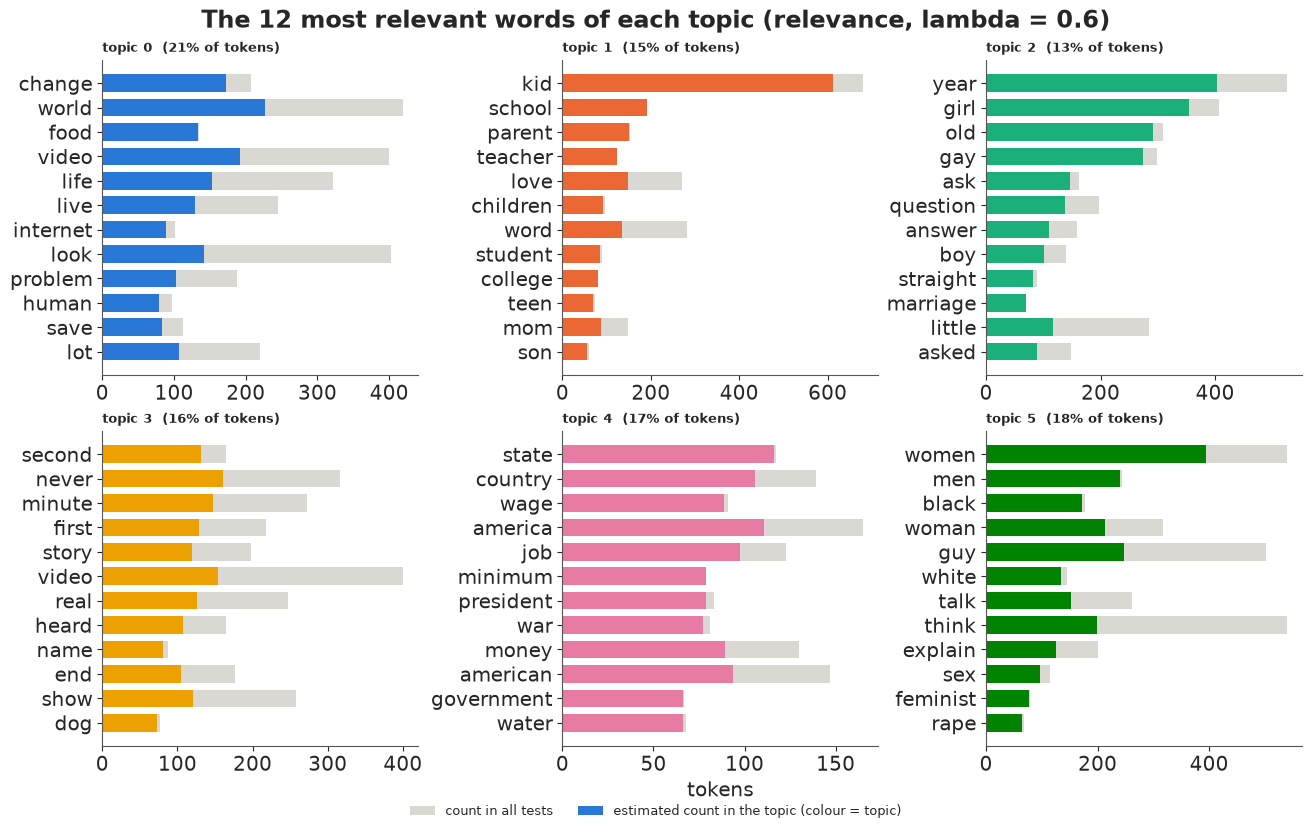

In [9]:
TOPIC_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]   # fixed order, never cycled
GREY_BAR, INK, MUTED = "#d9d8d3", "#0b0b0b", "#8a8984"

phi_ref = phi_mean_c[0]
word_count = X_txt.sum(0)
p_word = word_count / word_count.sum()
tokens_in_topic = (theta_ref * X_txt.sum(1)[:, None]).sum(0)        # expected tokens per topic
LAMBDA = 0.6
relevance = LAMBDA * np.log(phi_ref) + (1 - LAMBDA) * np.log(phi_ref / p_word)
labels_rel = [" / ".join(vocab[np.argsort(-relevance[k])[:3]]) for k in range(K_TXT)]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for k, ax in enumerate(axes.ravel()):
    top = np.argsort(-relevance[k])[:12][::-1]
    ax.barh(range(12), word_count[top], color=GREY_BAR, height=0.72, label="count in all tests")
    ax.barh(range(12), phi_ref[k, top] * tokens_in_topic[k], color=TOPIC_COLOURS[k], height=0.72,
            label="estimated count in this topic")
    ax.set_yticks(range(12), vocab[top])
    ax.set_title(f"topic {k}  ({tokens_in_topic[k] / tokens_in_topic.sum():.0%} of tokens)",
                 fontsize=9, loc="left")
    ax.grid(axis="y", visible=False)
handles, names = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["count in all tests", "estimated count in the topic (colour = topic)"], loc="lower center",
           ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.03))
axes[1, 1].set_xlabel("tokens")
fig.suptitle(f"The 12 most relevant words of each topic (relevance, lambda = {LAMBDA})");
print("top-3 words by probability vs by relevance:")
print(pd.DataFrame({"probability": labels_txt, "relevance": labels_rel}, index=[f"topic {k}" for k in range(K_TXT)]))

The grey bars expose the generic words: "video", "look", "world", "think", "guy" are frequent in
*every* topic, and a probability ranking lists them first. Relevance brings forward the words that
say what a topic is about. Topic 4 is policy ("wage", "minimum", "government", "president",
"war", "water"). Topic 2 is not only "year / girl / old" but also "gay", "straight", "marriage":
LGBT stories and stories that introduce a person by age share their "ask / question / answer"
framing. Topic 5 is gender *and race* ("black", "white", "feminist", "rape"), and topic 3 is the
viral-video topic ("second", "minute", "name", "dog").

**2. A map of the topics, with its uncertainty.** Topics are distributions over words, so they
have distances: the Jensen-Shannon distance between two topics' word distributions (0 = the same
words in the same proportions, 1 = no words in common). Classical multidimensional scaling places
the topics in a plane so that these distances are kept as well as possible. LDAvis shows only the
fitted topics; here the matched topics of all four chains are placed in the same map. A topic
whose four versions sit on top of each other is stable, and one whose versions spread out is
the fuzzy kind that part B's table warned about. Circle area is the topic's share of the corpus.

MDS keeps 37% of the squared-distance variation


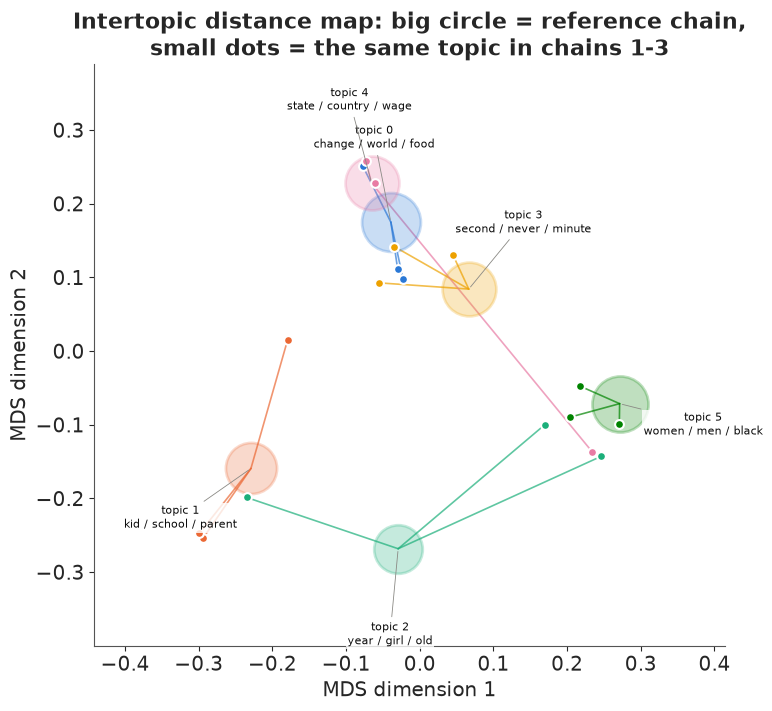

In [10]:
def js_distance(P, Q):
    M = 0.5 * (P + Q)
    return np.sqrt(0.5 * np.sum(P * np.log(P / M), -1) + 0.5 * np.sum(Q * np.log(Q / M), -1))


all_topics = phi_mean_c.reshape(-1, len(vocab))                      # (chain x topic) x word
D_js = js_distance(all_topics[:, None], all_topics[None])
n_all = len(D_js)
J = np.eye(n_all) - 1 / n_all
eigval, eigvec = np.linalg.eigh(-0.5 * J @ D_js**2 @ J)
xy = (eigvec[:, -2:] * np.sqrt(eigval[-2:]))[:, ::-1].reshape(4, K_TXT, 2)
share_topic = theta_txt.mean((1, 2))                                    # chain x topic
print(f"MDS keeps {eigval[-2:].sum() / eigval[eigval > 0].sum():.0%} of the squared-distance variation")

fig, ax = plt.subplots(figsize=(8.5, 7))
for k in range(K_TXT):
    for c in range(1, 4):
        ax.plot(*np.c_[xy[0, k], xy[c, k]], color=TOPIC_COLOURS[k], lw=1.2, alpha=0.7, zorder=1)
        ax.scatter(*xy[c, k], s=40, color=TOPIC_COLOURS[k], edgecolor="white", lw=1.5, zorder=3)
    ax.scatter(*xy[0, k], s=share_topic[0, k] * 9000, color=TOPIC_COLOURS[k], alpha=0.25,
               edgecolor=TOPIC_COLOURS[k], lw=2, zorder=2)
    out = xy[0, k] - xy[0].mean(0)                                     # push labels away from the centre
    out = out / np.linalg.norm(out)
    ax.annotate(f"topic {k}\n{labels_rel[k]}", xy[0, k], xytext=out * 62, textcoords="offset points",
                ha="center", va="center", fontsize=8, color=INK,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1),
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6))
ax.set(xlabel="MDS dimension 1", ylabel="MDS dimension 2", aspect="equal",
       title="Intertopic distance map: big circle = reference chain,\nsmall dots = the same topic in chains 1-3")
ax.margins(0.25);

Read the map for neighbourhoods, not exact distances: two dimensions keep only 37% of the
distance variation. Topics 1 (kid / school) and 5 (women / men) are tight clusters - all four
chains found them. Topics 2 and 4 are not: one chain's version of topic 4 sits next to topic 5,
and topic 2's versions are pulled towards topic 5 and topic 1. This is part B's stability table
drawn as a picture, and it shows *where* the unstable topics go: the chains share out the same
gender, LGBT and family words in different ways. Topics 0, 3 and 4 crowd the centre because
they share the generic "video / world" vocabulary.

**3. Topics inside a document.** A topic is easiest to understand where it lives. Each headline
below has its words highlighted by their most probable topic *in that story*, which is
proportional to $\theta_{dk}\,\phi_{kw}$: the same word can take different topics in different
stories. The small bar on the left is the story's topic mix $\theta_d$. Unhighlighted words are
stopwords or too rare to be in the vocabulary. We show stories that mix at least two topics.

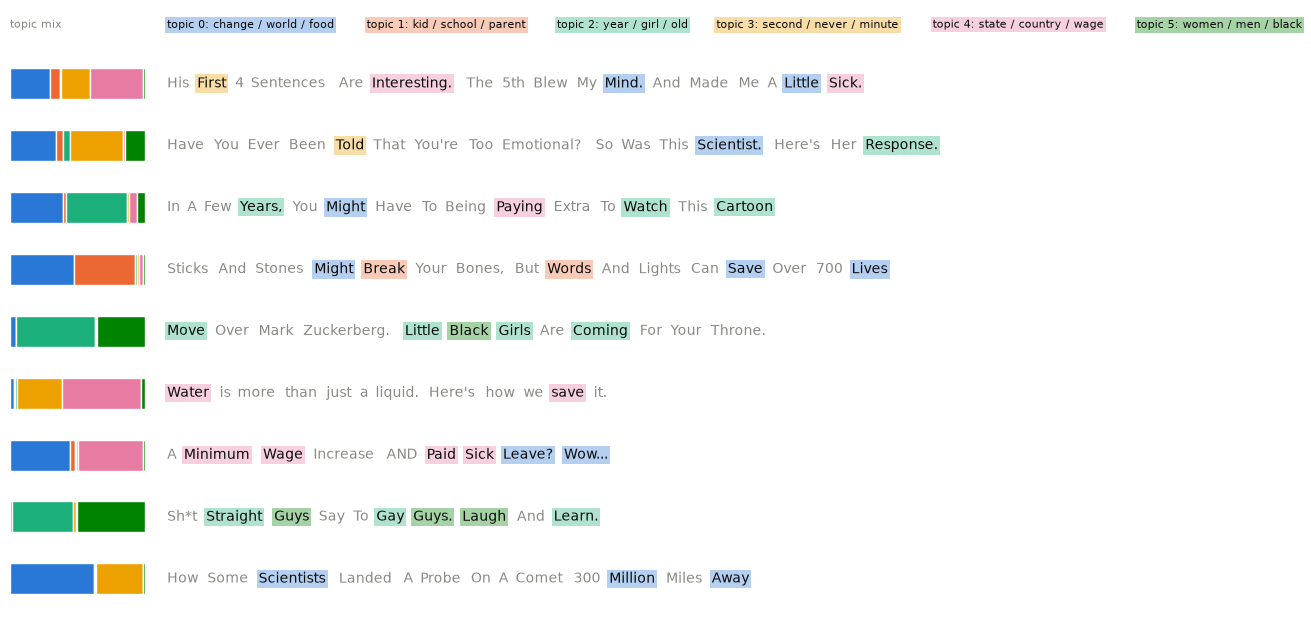

In [11]:
def headline_tokens(word):
    toks = tokens(word)
    return fold.get(toks[0], toks[0]) if toks else None


two_topic = np.flatnonzero(np.sort(theta_ref, 1)[:, -2] > 0.3)
rows = np.random.default_rng(8).choice(two_topic, 9, replace=False)
fig, ax = plt.subplots(figsize=(13, 0.55 * len(rows) + 1.2))
ax.set(xlim=(0, 1), ylim=(len(rows) - 0.4, -1.2))
ax.axis("off")
renderer = fig.canvas.get_renderer()
to_data = ax.transData.inverted()
for r, d in enumerate(rows):
    left = 0.0
    for k in range(K_TXT):                                        # the story's mixture
        ax.barh(r, theta_ref[d, k] * 0.12, left=left, height=0.5, color=TOPIC_COLOURS[k],
                edgecolor="white", lw=1)
        left += theta_ref[d, k] * 0.12
    x = 0.14
    for word in first_headline[test_ids[d]].split():
        t = ax.text(x, r, word, va="center", fontsize=10, color=INK)
        w = headline_tokens(word)
        if w in w_index:
            k_w = int(np.argmax(theta_ref[d] * phi_ref[:, w_index[w]]))
            t.set_bbox(dict(facecolor=TOPIC_COLOURS[k_w], alpha=0.35, edgecolor="none", pad=1.5))
        else:
            t.set_color(MUTED)
        x = to_data.transform((t.get_window_extent(renderer).x1, 0))[0] + 0.005
x = 0.14
for k in range(K_TXT):                                            # legend row, laid out by measured width
    t = ax.text(x, -0.95, f"topic {k}: {labels_rel[k]}", fontsize=8, color=INK, va="center",
                bbox=dict(facecolor=TOPIC_COLOURS[k], alpha=0.35, edgecolor="none", pad=1.5))
    x = to_data.transform((t.get_window_extent(renderer).x1, 0))[0] + 0.012
ax.text(0, -0.95, "topic mix", fontsize=8, color=MUTED, va="center");

Highlighting makes the mixture idea concrete. "A Minimum Wage Increase AND Paid Sick Leave" is
mostly the policy topic, with its "Wow" and "Leave?" from the causes topic. The same word can
change topic with the story: "Little" is in topic 0 in the first headline and in topic 2 in
"Little Black Girls Are Coming For Your Throne", where the story's mixture favours topic 2. Many
words are grey: with a vocabulary of 652 words and headlines of about a dozen words, most of a
headline is invisible to the model - one reason these topics are fuzzy.

**4. How much of the corpus is each topic, month by month?** A topic's prevalence in a month is
the average $\theta_{dk}$ over that month's stories. Two sources of uncertainty go into the
bands: the mixtures themselves (one line per saved Gibbs sweep) and *which* stories happened to
be tested that month (a Bayesian bootstrap: Dirichlet weights over the month's tests). Small
multiples on a shared axis rather than a stacked area chart, so each topic can be read against
a straight baseline.

tests per month: min 7, median 156, max 392


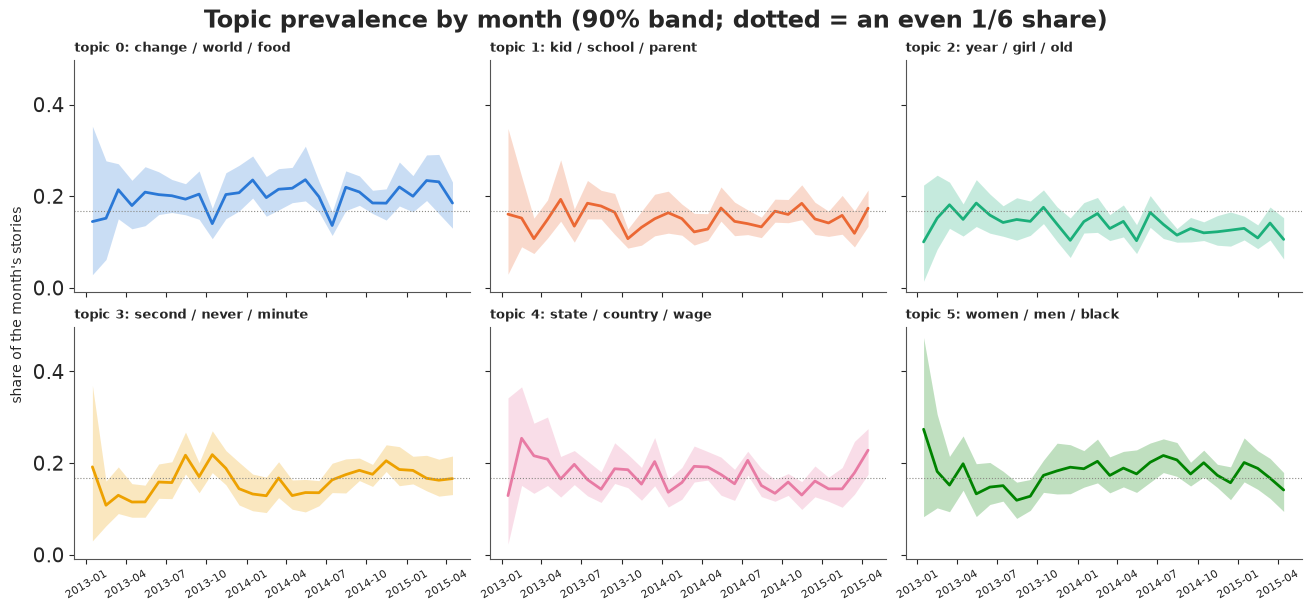

In [12]:
week = uw.groupby("test_id")["test_week"].first().loc[test_ids].to_numpy()
year, wk = week // 100, week % 100
month = (year - year.min()) * 12 + np.minimum((wk - 1) * 12 // 52, 11)      # months since Jan 2013
month_idx, month_codes = pd.factorize(month, sort=True)
month_dates = pd.to_datetime([f"{2013 + m // 12}-{m % 12 + 1:02d}-15" for m in month_codes])
g_prev = np.random.default_rng(9)
prev = np.zeros((theta_txt.shape[1], len(month_codes), K_TXT))
for m in range(len(month_codes)):
    idx = np.flatnonzero(month_idx == m)
    weights = g_prev.dirichlet(np.ones(len(idx)), size=theta_txt.shape[1])      # draw x test
    prev[:, m] = np.einsum("st,stk->sk", weights, theta_txt[0][:, idx])
tests_per_month = np.bincount(month_idx)
print(f"tests per month: min {tests_per_month.min()}, median {np.median(tests_per_month):.0f}, max {tests_per_month.max()}")

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    lo, hi = np.quantile(prev[..., k], [0.05, 0.95], axis=0)
    ax.fill_between(month_dates, lo, hi, color=TOPIC_COLOURS[k], alpha=0.25, lw=0)
    ax.plot(month_dates, prev[..., k].mean(0), color=TOPIC_COLOURS[k], lw=2)
    ax.axhline(1 / K_TXT, color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"topic {k}: {labels_rel[k]}", fontsize=9, loc="left")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.supylabel("share of the month's stories", fontsize=10)
fig.suptitle("Topic prevalence by month (90% band; dotted = an even 1/6 share)");

Most topics hold a roughly steady share. Two drift: "women / men / black" goes from about
0.12-0.15 of stories in mid-2013 to about 0.2 through 2014, and "year / girl / old" slides from
about 0.15-0.18 in 2013 to about 0.12 in 2015. The first months are wide because they have few
tests (7 in the smallest month). Remember that the topics were fitted to the whole period: a
topic whose *vocabulary* changes over time (a dynamic topic model; Blei & Lafferty 2006) is a
different model.

## C. How many topics, and do topics predict clicks?

### The usual answer: held-out likelihood

The textbook way to choose $K$ is **document completion**: fit on 80% of the tests, then for each
held-out test show the model half of its tokens, infer that test's mixture $\theta$ (with the
topics fixed), and score the log-probability of the other half. Larger is better. The baseline
is a single "topic" (word frequencies of the whole corpus).

In [13]:
@numba.njit
def _foldin_sweeps(doc, word, z, ndk, phi, alpha, n_sweeps, seed):
    np.random.seed(seed)
    K = phi.shape[0]
    cum = np.empty(K)
    for _ in range(n_sweeps):
        for i in range(doc.shape[0]):
            d, w, k = doc[i], word[i], z[i]
            ndk[d, k] -= 1
            total = 0.0
            for j in range(K):
                total += (ndk[d, j] + alpha) * phi[j, w]
                cum[j] = total
            u = np.random.random() * total
            k = 0
            while cum[k] < u:
                k += 1
            z[i] = k
            ndk[d, k] += 1


def completion_score(X_seen, X_hidden, phis, alpha=0.1, sweeps=50, seed=0):
    """Log-probability per hidden token, theta inferred from the seen half, averaged over phi draws."""
    g = np.random.default_rng(seed)
    d_i, w_i = np.nonzero(X_seen)
    n = X_seen[d_i, w_i]
    doc, word = np.repeat(d_i, n), np.repeat(w_i, n)
    K = phis.shape[1]
    prob = np.zeros(X_hidden.shape)
    for s, phi_s in enumerate(phis):
        z = g.integers(K, size=doc.size)
        ndk = np.zeros((X_seen.shape[0], K), np.int64)
        np.add.at(ndk, (doc, z), 1)
        _foldin_sweeps(doc, word, z, ndk, phi_s, alpha, sweeps, seed + s)
        prob += (ndk + alpha) / (ndk.sum(1, keepdims=True) + K * alpha) @ phi_s
    return np.sum(X_hidden * np.log(prob / len(phis))) / X_hidden.sum()


split_rng = np.random.default_rng(1)
is_test = split_rng.random(len(X_txt)) < 0.2
X_train, X_test = X_txt[~is_test], X_txt[is_test]
X_seen = np.zeros_like(X_test)
for d in range(len(X_test)):
    toks = np.repeat(np.arange(len(vocab)), X_test[d])
    split_rng.shuffle(toks)
    np.add.at(X_seen[d], toks[: len(toks) // 2], 1)
X_hidden = X_test - X_seen
unigram = (X_train.sum(0) + 0.5) / (X_train.sum() + 0.5 * len(vocab))
print(f"one-topic baseline: {np.sum(X_hidden * np.log(unigram)) / X_hidden.sum():.3f} nats per token")

one-topic baseline: -6.170 nats per token


### The answer that fits the purpose: does it predict clicks?

We want topics for a reason: to learn which *kinds of story* got clicked. So score each $K$ by
how well the topic mixtures predict a test's click-through rate out of sample. Upworthy's
click-through moved a lot over these two years (quarterly averages from under 1% to about 3%),
so the outcome is the **log-odds of click-through minus that month's average** (a story is
compared with stories of the same month).
The score is the 5-fold cross-validated $R^2$ of a ridge regression on the posterior mean
mixtures - a quick screen; the model below does it properly. The topic model never sees
the clicks, so fitting it on all tests does not leak.

    held-out nats/token  CV R2 of click-through
K                                              
2                -6.143                   0.020
4                -6.102                   0.106
6                -6.083                   0.084
10               -6.037                   0.091
20               -5.975                   0.093
40               -5.833                   0.089
80               -5.759                   0.103


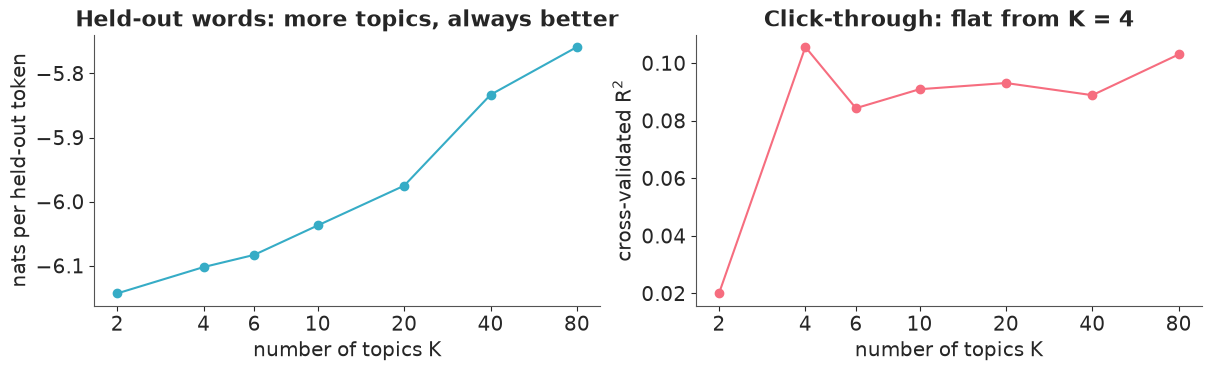

In [14]:
tests = uw.groupby("test_id").agg(clicks=("clicks", "sum"), impressions=("impressions", "sum"),
                                  week=("test_week", "first")).loc[test_ids]
logit_ctr = np.log((tests["clicks"] + 0.5) / (tests["impressions"] - tests["clicks"] + 0.5)).to_numpy()
year, wk = tests["week"].to_numpy() // 100, tests["week"].to_numpy() % 100
month = (year - year.min()) * 12 + np.minimum((wk - 1) * 12 // 52, 11)
month_idx, month_codes = pd.factorize(month, sort=True)
y_rel = logit_ctr - pd.Series(logit_ctr).groupby(month_idx).transform("mean").to_numpy()
cv_fold = np.random.default_rng(2).integers(5, size=len(y_rel))


def cv_r2(F, lam=1.0):
    pred = np.zeros_like(y_rel)
    for f in range(5):
        tr = cv_fold != f
        A = np.c_[np.ones(tr.sum()), F[tr]]
        b = np.linalg.solve(A.T @ A + lam * np.eye(A.shape[1]), A.T @ y_rel[tr])
        pred[~tr] = np.c_[np.ones((~tr).sum()), F[~tr]] @ b
    return 1 - np.mean((y_rel - pred) ** 2) / np.var(y_rel)


rows = []
for K in [2, 4, 6, 10, 20, 40, 80]:
    phi_tr, _, _ = lda_gibbs(X_train, K, burn=500, draws=10, thin=20, seed=K)
    _, theta_all, _ = lda_gibbs(X_txt, K, burn=500, draws=10, thin=20, seed=100 + K)
    rows.append({"K": K, "held-out nats/token": completion_score(X_seen, X_hidden, phi_tr[::2], seed=K),
                 "CV R2 of click-through": cv_r2(theta_all.mean(0))})
choose = pd.DataFrame(rows).set_index("K")
print(choose.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(choose.index, choose.iloc[:, 0], "o-")
axes[0].set(xscale="log", xlabel="number of topics K", ylabel="nats per held-out token",
            title="Held-out words: more topics, always better")
axes[1].plot(choose.index, choose.iloc[:, 1], "o-", color="C1")
axes[1].set(xscale="log", xlabel="number of topics K", ylabel="cross-validated R$^2$",
            title="Click-through: flat from K = 4")
for ax in axes:
    ax.minorticks_off()
    ax.set_xticks(choose.index, choose.index);

The two criteria disagree. Document completion keeps improving well beyond the point where
topics stop being readable: the headlines written for one story repeat that story's words, so
the more topics, the closer the model gets to memorising individual stories - an excellent way
to predict the other half of a headline set and a poor way to summarise a corpus. (Chang et al.
2009, "Reading tea leaves", found that held-out likelihood and human judgements of topic quality
can even move in opposite directions.) The click-through question has a clearer answer: a
handful of topics carries what the text says about clickability: two topics explain almost
nothing, and from four on the cross-validated $R^2$ stays around 0.08-0.11 with no trend (each $K$
is one LDA run, so differences of 0.02 are noise). We keep $K = 6$ - one of several equally
predictive choices, and still readable.

### Topics as regressors, with their uncertainty

Now the model. For test $d$ in month $m$, with observed log-odds $y_d$ and its binomial standard
error $s_d$ (known from clicks and impressions):

$$y_d \sim \text{Normal}\Big(\mu_{m} + \sum_k \theta_{dk}\,\gamma_k,\; \sqrt{\sigma^2 + s_d^2}\Big),
\qquad \mu_m \text{ a Gaussian random walk over months}, \qquad \sum_k \gamma_k = 0.$$

Because every $\boldsymbol\theta_d$ sums to one, an intercept and $K$ free topic effects are not
identified together; a `ZeroSumNormal` makes each $\gamma_k$ the effect of a story being entirely
about topic $k$ *relative to the average topic*. $\sigma$ is everything else about a story.

The mixtures $\theta_d$ are *estimates*, and for a 9-token document they are uncertain. There are
two tempting ways to use them:

1. **plug-in**: use each test's posterior mean mixture as if it were known;
2. **"propagate the uncertainty"**: fit the regression once for each of several posterior draws
   of $\theta$ and pool the posterior draws (multiple imputation).

We fit both. The model is compiled once (nutpie) and the data swapped between fits.

In [15]:
import nutpie

se_logit = np.sqrt(1 / (tests["clicks"] + 0.5) + 1 / (tests["impressions"] - tests["clicks"] + 0.5)).to_numpy()
coords_ctr = {"test": np.arange(len(logit_ctr)), "month": month_codes, "topic": labels_txt}
with pm.Model(coords=coords_ctr) as ctr_model:
    theta_data = pm.Data("theta_data", theta_txt[0].mean(0), dims=("test", "topic"))
    y_data = pm.Data("y_data", logit_ctr, dims="test")
    mu_month = pm.GaussianRandomWalk("mu_month", sigma=0.1, init_dist=pm.Normal.dist(-4.0, 1.0),
                                     dims="month")
    gamma = pm.ZeroSumNormal("gamma", sigma=0.5, dims="topic")
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.Normal("y", mu_month[month_idx] + theta_data @ gamma, pt.sqrt(sigma**2 + se_logit**2),
              observed=y_data, dims="test")

compiled_ctr = nutpie.compile_pymc_model(ctr_model)


def fit_gamma(theta_in, y_in, draws=1000, seed=0):
    fit = nutpie.sample(compiled_ctr.with_data(theta_data=theta_in, y_data=y_in), draws=draws, seed=seed,
                        save_warmup=False, progress_bar=False)
    return fit


def plugin_and_imputed(theta_draws, y_in, n_imp=8, seed=0):
    """Posterior draws of gamma: plug-in (posterior-mean mixtures) and pooled over n_imp mixture draws."""
    plug = fit_gamma(theta_draws.mean(0), y_in, seed=seed)
    picks = np.linspace(0, len(theta_draws) - 1, n_imp).astype(int)
    imp = [fit_gamma(theta_draws[p], y_in, draws=250, seed=seed + 1 + i).posterior["gamma"].values.reshape(-1, K_TXT)
           for i, p in enumerate(picks)]
    return plug, plug.posterior["gamma"].values.reshape(-1, K_TXT), np.concatenate(imp)


t0 = time.perf_counter()
fit_plugin, gamma_plugin, gamma_mi = plugin_and_imputed(theta_txt[0], logit_ctr, seed=RANDOM_SEED)
print(f"9 regressions: {time.perf_counter() - t0:.0f} s")
print("plug-in fit: divergences", int(fit_plugin.sample_stats["diverging"].sum()),
      "| max r_hat", round(float(az.rhat(fit_plugin.posterior["gamma"]).max()), 3))
print(pd.DataFrame({"plug-in mean": gamma_plugin.mean(0), "plug-in sd": gamma_plugin.std(0),
                    "imputed mean": gamma_mi.mean(0), "imputed sd": gamma_mi.std(0)},
                   index=labels_txt).round(3))

9 regressions: 4 s
plug-in fit: divergences 0 | max r_hat 1.003
                        plug-in mean  plug-in sd  imputed mean  imputed sd
world / video / change        -0.420       0.028        -0.284       0.028
kid / school / parent          0.027       0.032         0.010       0.030
year / girl / old              0.443       0.033         0.331       0.033
never / video / minute         0.207       0.031         0.125       0.028
state / reason / time         -0.449       0.030        -0.318       0.033
women / guy / men              0.192       0.029         0.136       0.026


The two disagree, and not in the way "propagating uncertainty" suggests: the imputed effects
are not just wider, they are about a third *smaller*. Which is right? Ask a simulation where we
know the answer. Take the fitted topics and one posterior draw of the mixtures as the truth,
generate a fake corpus with the real document lengths, generate fake click-through log-odds
with known effects $\gamma$ (the plug-in estimates), refit LDA to the fake corpus, align its
topics to the true ones, and run both regressions.

In [16]:
sim_rng = np.random.default_rng(7)
phi_truth, theta_truth = phi_txt[0].mean(0), theta_txt[0, -1]
gamma_truth = gamma_plugin.mean(0)
mu_hat = fit_plugin.posterior["mu_month"].mean(("chain", "draw")).values
sigma_hat = float(fit_plugin.posterior["sigma"].mean())
X_fake = np.array([sim_rng.multinomial(n, p) for n, p in zip(X_txt.sum(1), theta_truth @ phi_truth)])
y_fake = (mu_hat[month_idx] + theta_truth @ gamma_truth
          + sim_rng.normal(0, np.sqrt(sigma_hat**2 + se_logit**2)))
phi_f, theta_f, _ = lda_gibbs(X_fake, K_TXT, seed=11)
perm_f = align_to(phi_truth, phi_f.mean(0))
theta_f = theta_f[..., perm_f]
print("cosine of refitted topics to the true ones:", np.round(cosine(phi_truth, phi_f.mean(0)[perm_f]), 2))
_, g_plug_f, g_mi_f = plugin_and_imputed(theta_f, y_fake, seed=21)
_, g_true_f, _ = plugin_and_imputed(theta_truth[None], y_fake, n_imp=1, seed=31)
sim_tab = pd.DataFrame({"true gamma": gamma_truth, "true mixtures known": g_true_f.mean(0),
                        "plug-in": g_plug_f.mean(0), "imputed": g_mi_f.mean(0)}, index=labels_txt)
print(sim_tab.round(3))
slope = lambda est: np.sum(est * gamma_truth) / np.sum(gamma_truth**2)
print(f"estimate / truth (least-squares slope): plug-in {slope(g_plug_f.mean(0)):.2f}, "
      f"imputed {slope(g_mi_f.mean(0)):.2f}")

cosine of refitted topics to the true ones: [0.99 0.99 0.99 0.98 0.98 0.99]


                        true gamma  true mixtures known  plug-in  imputed
world / video / change      -0.420               -0.445   -0.419   -0.318
kid / school / parent        0.027                0.005    0.027    0.028
year / girl / old            0.443                0.460    0.431    0.332
never / video / minute       0.207                0.209    0.175    0.125
state / reason / time       -0.449               -0.465   -0.456   -0.355
women / guy / men            0.192                0.236    0.241    0.187
estimate / truth (least-squares slope): plug-in 1.00, imputed 0.77


The simulation settles it. With the true mixtures, the regression recovers the true effects (up
to noise); with **plug-in** posterior means it still does (slope 1.00 against the truth); pooling
over **posterior draws** shrinks every effect by about a quarter (0.77). The same shrinkage as on
the real data.

Why: a single posterior draw of $\theta_d$ is the posterior mean *plus noise that knows nothing
about clicks*. Noise added to a regressor is **classical measurement error**, and it attenuates
slopes. The posterior mean has the other kind of error: truth = estimate + noise independent of
the estimate (**Berkson** error), which leaves a linear regression's slope unbiased - this is
"regression calibration". The general rule behind it: multiple imputation is valid only when
the imputation model includes the outcome, and a topic model's posterior knows nothing about
clicks. The fully Bayesian alternative is one joint model in which clicks and words both inform
the mixtures - **supervised LDA** (Blei & McAuliffe 2007) - at a much higher computational cost.

A second lesson hides in the first line of output: on *fake* data drawn from LDA, a single chain
finds the true topics almost exactly (cosine 0.98-0.99). The instability of part B is therefore
not a sampler failure - it is what happens when real headlines are not generated by LDA and
several different six-topic summaries fit them about equally well.

So we report the plug-in effects. The plug-in standard deviations ignore the uncertainty in the
mixtures and are somewhat too small; with sd around 0.03 against effects of 0.2-0.45 that does
not change any conclusion here.

                        effect on log-odds     sd  P(effect > 0)  odds vs average story
world / video / change              -0.420  0.028          0.000                  0.657
kid / school / parent                0.027  0.032          0.805                  1.028
year / girl / old                    0.443  0.033          1.000                  1.558
never / video / minute               0.207  0.031          1.000                  1.230
state / reason / time               -0.449  0.030          0.000                  0.639
women / guy / men                    0.192  0.029          1.000                  1.213
sigma (story-to-story sd of log-odds): 0.545


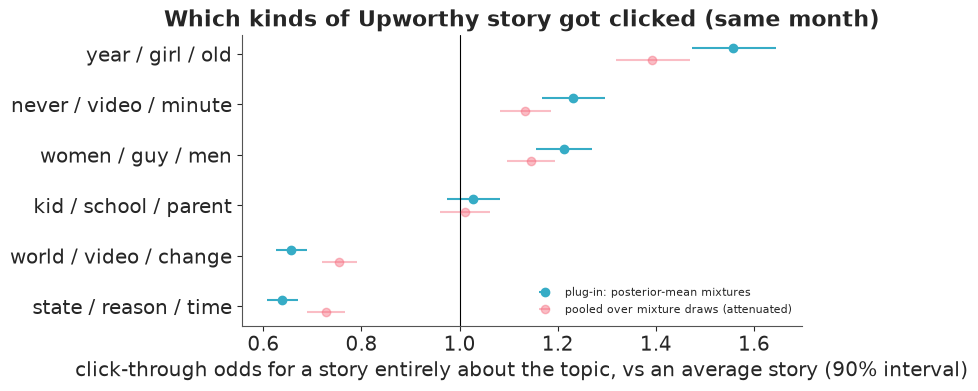

In [17]:
eff = pd.DataFrame({"effect on log-odds": gamma_plugin.mean(0), "sd": gamma_plugin.std(0),
                    "P(effect > 0)": (gamma_plugin > 0).mean(0),
                    "odds vs average story": np.exp(gamma_plugin).mean(0)}, index=labels_txt)
print(eff.round(3))
print("sigma (story-to-story sd of log-odds):", round(float(fit_plugin.posterior["sigma"].mean()), 3))

order = np.argsort(gamma_plugin.mean(0))
fig, ax = plt.subplots(figsize=(8, 3.8))
for j, (g_draws, name, off) in enumerate([(gamma_plugin, "plug-in: posterior-mean mixtures", 0.12),
                                           (gamma_mi, "pooled over mixture draws (attenuated)", -0.12)]):
    lo, hi = np.quantile(np.exp(g_draws), [0.05, 0.95], axis=0)
    mid = np.exp(g_draws).mean(0)
    ax.errorbar(mid[order], np.arange(K_TXT) + off, xerr=[mid[order] - lo[order], hi[order] - mid[order]],
                fmt="o", color=f"C{j}", alpha=1 if j == 0 else 0.45, label=name)
ax.axvline(1, color="k", lw=0.8)
ax.set_yticks(range(K_TXT), np.array(labels_txt)[order])
ax.set(xlabel="click-through odds for a story entirely about the topic, vs an average story (90% interval)",
       title="Which kinds of Upworthy story got clicked (same month)")
ax.legend(fontsize=8, loc="lower right");

Stories about the "year / girl / old" topic (a child or a person introduced by age, and questions
asked and answered - "gay" and "ask" are in it too) had about 1.5 times the click-through odds of
an average story of the same month; "never / video / minute" (watch-this-video stories) and
"women / guy / men" (gender, and race: "black", "white" are in it) about 1.2 times. Stories
about "state / reason / time" (America, jobs, money: policy) and "world / video / change" (big
causes: food, change, the world) had about two thirds of the average odds. "kid / school /
parent" is indistinguishable from average. The story-to-story sd of log-odds that topics do not
explain is 0.55 - topics are a small part of what made a story clickable. Topics are fuzzy (part B), so read these as
descriptions of *how stories clustered*, not as a lever: nothing here says that rewriting a
policy story as a family story would earn more clicks. That is a causal question, and the
headline experiments in E66 answer the version of it that can be answered (wording, within a
story).

## D. From posters to documents: a colour vocabulary

Now the same model on pictures. The collection: 750 public-domain posters from the Library of
Congress, 250 from each of three moments in the history of printed advertising and persuasion:

* **1890s magazine posters** - the American "poster craze", when magazines (*Harper's*, *The
  Century*, *Scribner's*, *Lippincott's*, *The Chap-Book*) commissioned artists such as Edward
  Penfield and Will Bradley to sell each month's issue;
* **First World War posters** (1914-1919) - recruitment, war loans, food conservation, relief;
* **WPA posters** (1936-1943) - the New Deal's Federal Art Project: health campaigns, theatre,
  travel, exhibitions, in silkscreen.

loc_posters_thumbs: NumPy .npz (open data.path(...) with np.load): thumbs (750 x 64 x 48 x 3 uint8 RGB, rows = height), era ('1890s magazine', 'WWI', 'WPA'; 250 each), year (first four-digit year in the LoC date), title, creator, loc_id, image_url. Many scans include the black or grey backing and a colour-checker strip around the poster (most often in the WWI group).
  source: Library of Congress Prints & Photographs Division: Posters collection (search 'magazine', dated 1889-1905; search 'world war 1914-1918', dated 1914-1919) and Work Projects Administration Poster Collection (co=wpapos, dated 1935-1943); public domain / no known restrictions on publication per the LoC rights statements. BUILT by tools/fetch_loc_posters.py (seed 72): 250 randomly sampled items per era with a dated year and a reference image; each 640-px reference JPEG (the URL's `image.full`) resized to 64 x 48 with Lanczos. Keep the cached file in data/ (a rebuild draws from whatever the live search returns).
  url:

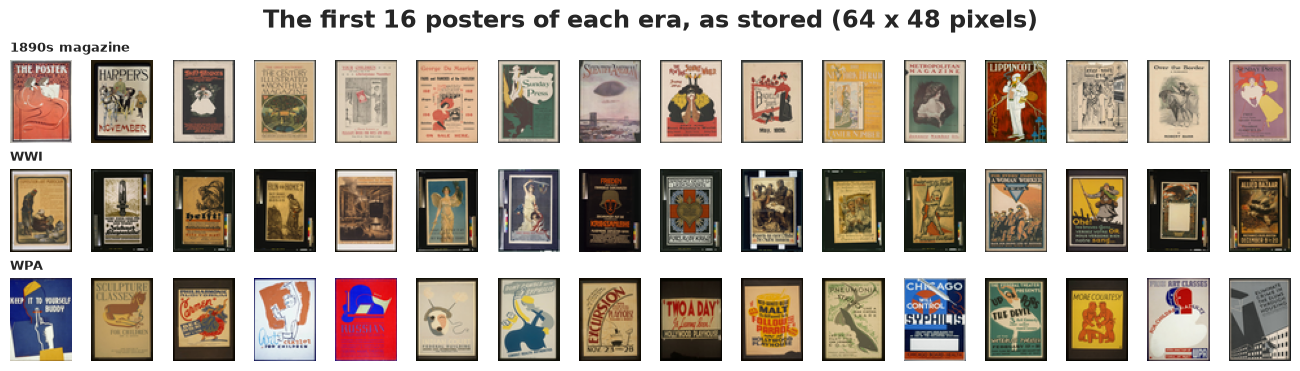

In [18]:
data.describe("loc_posters_thumbs")
posters = np.load(data.path("loc_posters_thumbs"))
thumbs, era, poster_year, poster_title = posters["thumbs"], posters["era"], posters["year"], posters["title"]
ERAS = ["1890s magazine", "WWI", "WPA"]
era_idx = np.array([ERAS.index(e) for e in era])
print(thumbs.shape, dict(zip(*np.unique(era, return_counts=True))))

fig, axes = plt.subplots(3, 16, figsize=(13, 3.6))
for r, e in enumerate(ERAS):
    for c, i in enumerate(np.flatnonzero(era_idx == r)[:16]):
        axes[r, c].imshow(thumbs[i])
        axes[r, c].axis("off")
    axes[r, 0].set_title(e, fontsize=9, loc="left")
fig.suptitle("The first 16 posters of each era, as stored (64 x 48 pixels)");

Look at the WWI row: many scans show the poster on a **black backing, with a colour-checker
strip** beside it. A topic model would learn "black scan background" as a palette - and since
it is far more common in one era, it would also look like an era effect. What the *measurement
pipeline* adds to every document of one kind is the pictorial version of boilerplate text
(copyright lines, e-mail footers), and it has to go before modelling. We estimate the backing
colour from the four corners and keep the rows and columns in which most pixels differ from it
(a crude crop: posters that are themselves dark at the edges keep their border).

Then the vocabulary. Colours are compared in **CIELab**, a colour space designed so that
Euclidean distance roughly matches perceived difference (RGB is not). A **codebook of 32
colours** is learned by k-means on a sample of pixels from all posters; each pixel becomes the
index of its nearest code colour - its "word". This is the "bag of visual words" idea from
computer vision, with colours as the simplest possible visual words (patches, textures or
features from a neural network work the same way).

share of the thumbnail kept, median by era: {'1890s magazine': 0.88, 'WWI': 0.71, 'WPA': 0.81}


{'red': '13, 14, 15, 16', 'orange': '18', 'yellow': '22, 26, 27', 'green': '31', 'blue': '8, 9, 10, 11, 12', 'beige': '17, 23, 25, 28, 29, 30', 'brown': '19, 20, 21', 'grey': '0, 1, 2, 3, 4, 5, 6, 7, 24'}


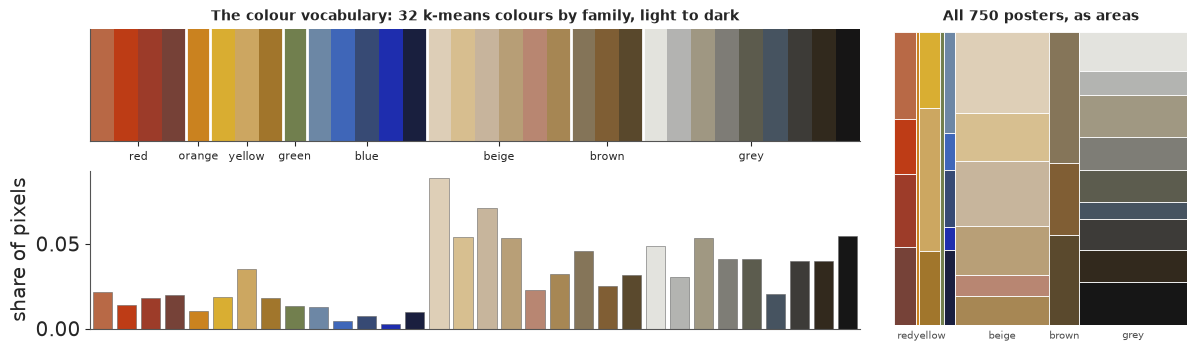

In [19]:
M_XYZ = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])
WHITE = np.array([0.95047, 1.0, 1.08883])


def rgb_to_lab(rgb):
    c = np.asarray(rgb, float) / 255
    c = np.where(c > 0.04045, ((c + 0.055) / 1.055) ** 2.4, c / 12.92)
    f = c @ M_XYZ.T / WHITE
    f = np.where(f > (6 / 29) ** 3, np.cbrt(f), f / (3 * (6 / 29) ** 2) + 4 / 29)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def lab_to_rgb(lab):
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    xyz = np.where(f > 6 / 29, f**3, 3 * (6 / 29) ** 2 * (f - 4 / 29)) * WHITE
    c = np.clip(xyz @ np.linalg.inv(M_XYZ).T, 0, 1)
    return np.clip(np.where(c > 0.0031308, 1.055 * c ** (1 / 2.4) - 0.055, 12.92 * c), 0, 1)


def crop_box(img, threshold=12.0, frac=0.6):
    """Rows/columns where most pixels differ (Delta E > threshold) from the median corner colour."""
    lab = rgb_to_lab(img)
    corners = np.concatenate([lab[:3, :3], lab[:3, -3:], lab[-3:, :3], lab[-3:, -3:]]).reshape(-1, 3)
    fg = np.linalg.norm(lab - np.median(corners, 0), axis=-1) > threshold
    rows, cols = np.flatnonzero(fg.mean(1) > frac), np.flatnonzero(fg.mean(0) > frac)
    if len(rows) < 16 or len(cols) < 12:          # nothing clearly separable: keep the whole image
        return 0, img.shape[0], 0, img.shape[1]
    return rows[0] + 1, rows[-1], cols[0] + 1, cols[-1]   # one more pixel in, for resampling halos


def nearest(lab_pixels, codebook, chunk=100_000):
    out = np.empty(len(lab_pixels), np.int64)
    for s in range(0, len(lab_pixels), chunk):   # chunks: a pixels x codebook x 3 array gets big
        d2 = ((lab_pixels[s:s + chunk, None, :] - codebook[None]) ** 2).sum(-1)
        out[s:s + chunk] = d2.argmin(1)
    return out


def kmeans(x, k, g, iters=50):
    centres = [x[g.integers(len(x))]]
    for _ in range(k - 1):                        # k-means++ seeding
        d2 = ((x[:, None] - np.array(centres)[None]) ** 2).sum(-1).min(1)
        centres.append(x[g.choice(len(x), p=d2 / d2.sum())])
    centres = np.array(centres)
    for _ in range(iters):
        lab = nearest(x, centres)
        centres = np.array([x[lab == j].mean(0) if np.any(lab == j) else centres[j] for j in range(k)])
    return centres


boxes = np.array([crop_box(t) for t in thumbs])
kept_share = (boxes[:, 1] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 2]) / (64 * 48)
print("share of the thumbnail kept, median by era:",
      {e: round(float(np.median(kept_share[era_idx == i])), 2) for i, e in enumerate(ERAS)})
poster_lab = [rgb_to_lab(t[r0:r1, c0:c1]).reshape(-1, 3) for t, (r0, r1, c0, c1) in zip(thumbs, boxes)]

V_COL = 32
g_col = np.random.default_rng(3)
pixel_sample = np.concatenate([p[g_col.choice(len(p), 60, replace=False)] for p in poster_lab])
codebook = kmeans(pixel_sample, V_COL, g_col)
chroma, hue = np.hypot(codebook[:, 1], codebook[:, 2]), np.arctan2(codebook[:, 2], codebook[:, 1])
codebook = codebook[np.lexsort((codebook[:, 0], np.where(chroma < 12, -10, np.round(hue * 2))))]  # greys, then by hue
swatch = lab_to_rgb(codebook)
chroma, hue = np.hypot(codebook[:, 1], codebook[:, 2]), np.arctan2(codebook[:, 2], codebook[:, 1])
poster_words = [nearest(p, codebook) for p in poster_lab]

# For display, colours are grouped into families: the chromatic ones in hue order (red, orange,
# yellow, green, blue), then the earth tones and neutrals that dominate old paper (beige/tan,
# brown, grey), sorted light to dark within a family. CIELab hue alone would call every beige and
# brown "yellow" (they sit at hue angles of 70-95 degrees), so lightness and chroma split them off.
FAMILIES = ["red", "orange", "yellow", "green", "blue", "beige", "brown", "grey"]
hue_deg = np.degrees(hue) % 360
code_family = np.select(
    [chroma < 13,                                            # grey: too little colour to have a hue
     (hue_deg >= 105) & (hue_deg < 200),                     # green
     hue_deg >= 200,                                         # blue (no violets in this vocabulary)
     (hue_deg < 55) & (chroma >= 22) & (codebook[:, 0] < 58),  # red, brick, maroon
     (chroma >= 40) & (hue_deg < 75),                        # orange
     chroma >= 40,                                           # yellow: gold and ochre
     codebook[:, 0] < 50],                                   # brown: dark, muted warm
    [7, 3, 4, 0, 1, 2, 6], 5)                                # otherwise beige / tan
print({f: ", ".join(map(str, np.flatnonzero(code_family == i))) for i, f in enumerate(FAMILIES)})
display_order = np.lexsort((-codebook[:, 0], code_family))


def palette_squares(ax, weights, labels=True, min_label=0.1):
    """A colour distribution as a unit square: one column per colour family (width = the family's
    share; chromatic families in hue order, then beige, brown, grey), its colours stacked light (top)
    to dark (height = share within the family). Every rectangle's area is the colour's share."""
    w = np.asarray(weights, float) / np.sum(weights)
    x = 0.0
    for f in range(len(FAMILIES)):
        members = display_order[code_family[display_order] == f]
        total = w[members].sum()
        if total < 1e-4:
            continue
        y = 1.0
        for j in members:
            h = w[j] / total
            ax.add_patch(plt.Rectangle((x, y - h), total, h, facecolor=swatch[j], edgecolor="white", lw=0.6))
            y -= h
        if labels and total >= min_label:
            ax.text(x + total / 2, -0.02, FAMILIES[f], ha="center", va="top", fontsize=7, color="0.3")
        x += total
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal")
    ax.axis("off")


share_all = np.bincount(np.concatenate(poster_words), minlength=V_COL) / sum(map(len, poster_words))
fig = plt.figure(figsize=(12, 3.4))
left, right = fig.subfigures(1, 2, width_ratios=[2.6, 1])
axes = left.subplots(2, 1, height_ratios=[1, 1.4])
axes[0].imshow(swatch[display_order][None], aspect="auto")
axes[0].set(yticks=[])
axes[0].set_title("The colour vocabulary: 32 k-means colours by family, light to dark", fontsize=10)
fam_sorted = code_family[display_order]
starts = [np.flatnonzero(fam_sorted == f) for f in range(len(FAMILIES))]
axes[0].set_xticks([s_.mean() for s_ in starts if len(s_)], [FAMILIES[f] for f, s_ in enumerate(starts) if len(s_)],
                   fontsize=8)
for s_ in starts[1:]:
    if len(s_):
        axes[0].axvline(s_[0] - 0.5, color="white", lw=2)
axes[1].bar(range(V_COL), share_all[display_order], color=swatch[display_order], edgecolor="0.4", lw=0.4)
axes[1].set(xlim=(-0.5, V_COL - 0.5), xticks=[], ylabel="share of pixels")
palette_squares(right.subplots(), share_all, min_label=0.05)
right.suptitle("All 750 posters, as areas", fontsize=10);

**Reading the square charts.** From here on, any colour distribution - a poster, a palette, an
era - is drawn as a square in which every rectangle's *area* is a colour's share. Columns are
colour families (red, orange, yellow, green, blue, then beige, brown and grey), always in that
order, with widths equal to the family's share; within a column the colours are stacked light to
dark. Because the order never changes, two squares can be compared position by position: a wide
grey column on the right, a thin red sliver on the left. (A strip or a pie ranks colours by
weight and loses this.)

Each poster is now a document of colour words. How many tokens should a crop of about 2,600
pixels contribute? LDA's multinomial treats tokens as independent draws, but neighbouring pixels
are nearly copies of each other, so 2,600 pixels carry far less than 2,600 independent pieces of
evidence. We take **200 randomly chosen pixels per poster** as its tokens (equal length for every
document), and part G checks what that choice does.

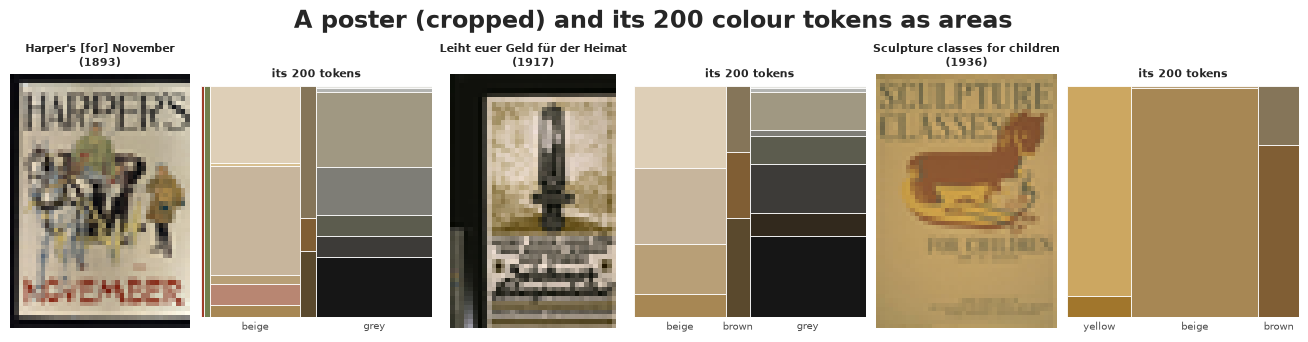

In [20]:
N_TOK = 200
X_col = np.array([np.bincount(w[g_col.choice(len(w), N_TOK, replace=False)], minlength=V_COL)
                  for w in poster_words])

fig, axes = plt.subplots(1, 6, figsize=(13, 3.3), width_ratios=[1, 1.25] * 3)
for c, i in enumerate([np.flatnonzero(era_idx == r)[1] for r in range(3)]):
    r0, r1, c0, c1 = boxes[i]
    axes[2 * c].imshow(thumbs[i][r0:r1, c0:c1])
    axes[2 * c].axis("off")
    axes[2 * c].set_title(f"{poster_title[i][:30]}\n({poster_year[i]})", fontsize=8)
    palette_squares(axes[2 * c + 1], X_col[i])
    axes[2 * c + 1].set_title("its 200 tokens", fontsize=8)
fig.suptitle("A poster (cropped) and its 200 colour tokens as areas");

## E. Palette topics

The corpus is small in vocabulary (32) and long in documents (200 tokens), the opposite of the
headlines. We fit $K = 6$ palettes. The PyMC model of part A runs here, but slowly: while
preparing the notebook it needed ~3 minutes with the maximum tree depth on almost every
transition, and its four chains agreed on only some of the palettes. The collapsed Gibbs sampler
of part B takes about two seconds per run, so we run it from **8 random starts** and compare:
the restart with the highest likelihood is our palette set, and the agreement between restarts
says which palettes are robust.

In [21]:
K_COL = 6
t0 = time.perf_counter()
col_runs = [lda_gibbs(X_col, K_COL, alpha=0.5, beta=0.5, burn=1000, draws=20, thin=10, seed=s) for s in range(8)]
print(f"8 restarts: {time.perf_counter() - t0:.0f} s")
col_ll = np.array([r[2].mean() for r in col_runs])
best = int(np.argmax(col_ll))
print("mean token log-likelihood per restart:", np.round(col_ll - col_ll.max()), "(best = 0)")

phi_col_draws = col_runs[best][0]
phi_col = phi_col_draws.mean(0)
theta_col = col_runs[best][1].mean(0)
# order palettes by how much of the corpus they explain
pal_order = np.argsort(-theta_col.mean(0))
phi_col_draws, phi_col, theta_col = phi_col_draws[:, pal_order], phi_col[pal_order], theta_col[:, pal_order]
match = []
for s, r in enumerate(col_runs):
    other = r[0].mean(0)
    perm = linear_sum_assignment(-cosine(phi_col[:, None], other[None]))[1]
    match.append(cosine(phi_col, other[perm]))
match = np.array(match)
print("palette similarity to its best match in each restart (min / median):")
print(pd.DataFrame({"min": match.min(0), "median": np.median(match, 0)},
                   index=[f"palette {k}" for k in range(K_COL)]).round(2).T)

8 restarts: 18 s
mean token log-likelihood per restart: [-9741. -1415.  -574.   -23. -1064.  -980. -2570.     0.] (best = 0)
palette similarity to its best match in each restart (min / median):
        palette 0  palette 1  palette 2  palette 3  palette 4  palette 5
min          0.96       0.16       0.71       0.16       0.41       0.68
median       1.00       0.96       0.99       0.96       0.83       1.00


largest posterior sd of any colour share in any palette: 0.0047


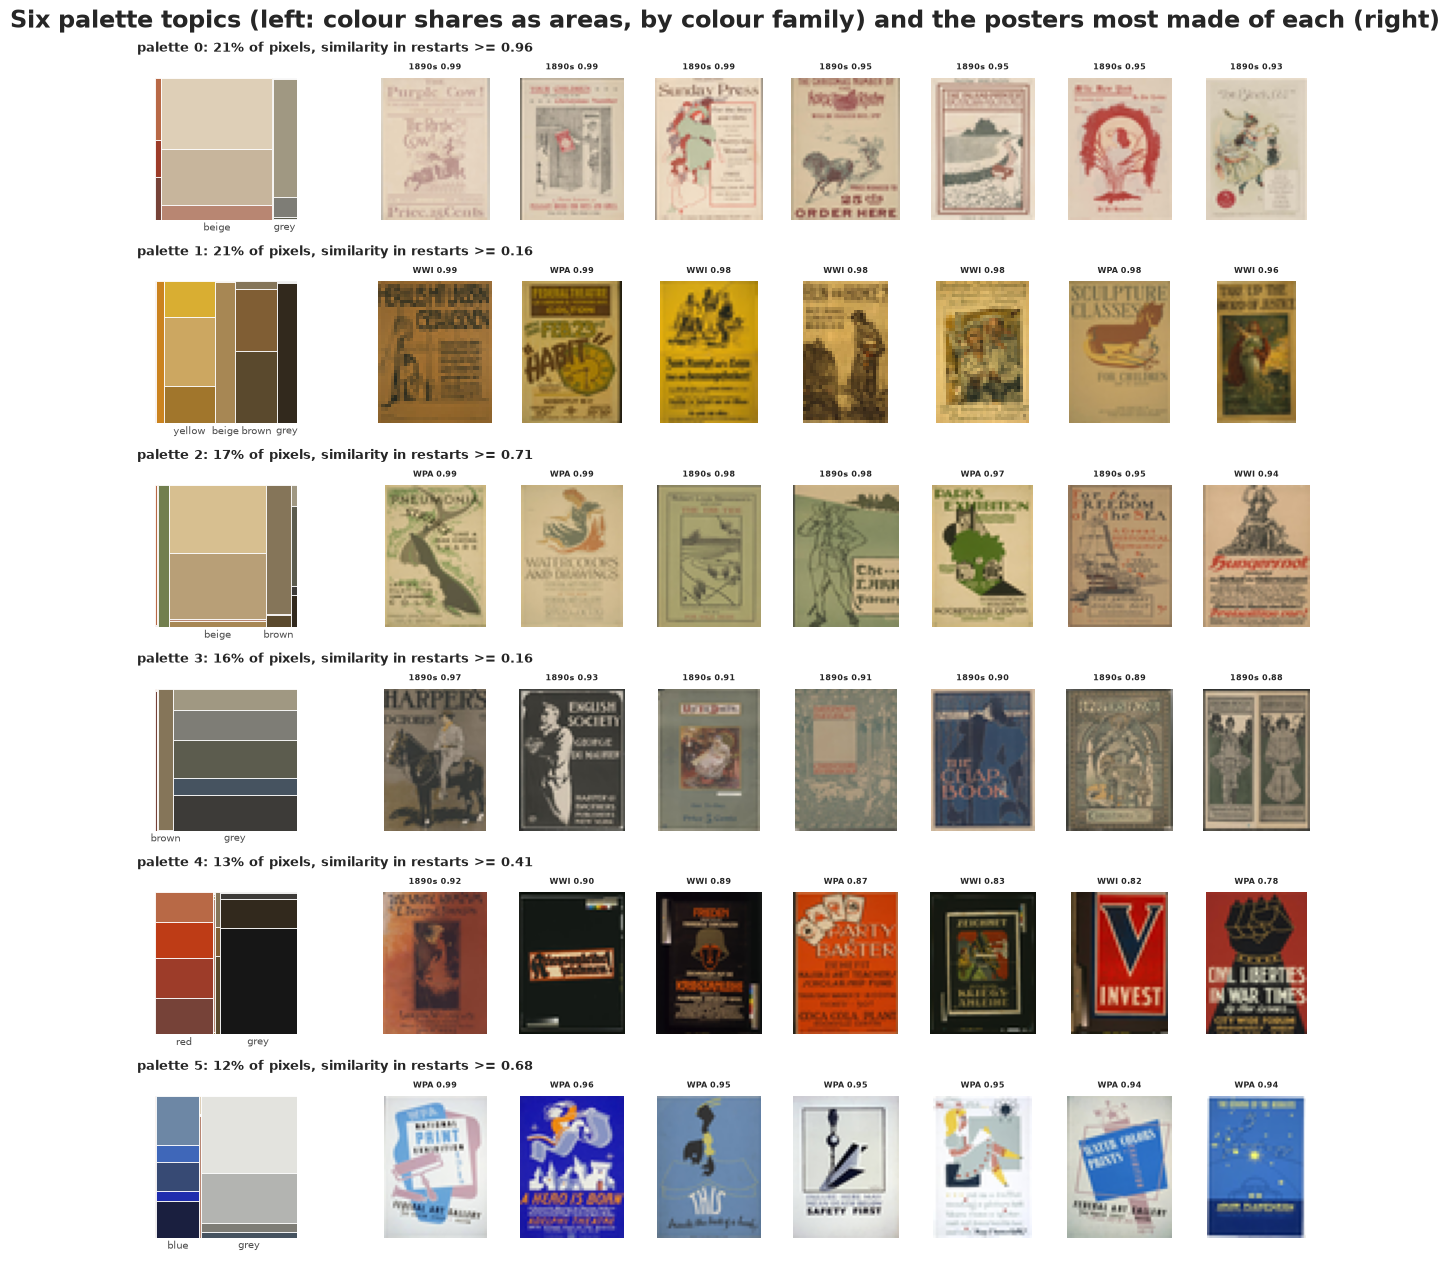

In [22]:
def palette_bar(ax, weights, lw=0):
    o = display_order
    ax.barh(0, weights[o], left=np.r_[0, np.cumsum(weights[o])[:-1]], color=swatch[o], edgecolor="none", height=1)
    ax.set(xlim=(0, 1), ylim=(-0.5, 0.5))
    ax.axis("off")


fig = plt.figure(figsize=(12, 12.5))
sub = fig.subfigures(K_COL, 1)
for k in range(K_COL):
    axes = sub[k].subplots(1, 9, width_ratios=[1.5, 0.25] + [1] * 7)
    palette_squares(axes[0], phi_col[k])
    sub[k].suptitle(f"palette {k}: {theta_col[:, k].mean():.0%} of pixels, "
                    f"similarity in restarts >= {match[:, k].min():.2f}", fontsize=9, x=0.01, ha="left")
    axes[1].axis("off")
    for ax, i in zip(axes[2:], np.argsort(-theta_col[:, k])[:7]):
        r0, r1, c0, c1 = boxes[i]
        ax.imshow(thumbs[i][r0:r1, c0:c1])
        ax.set_title(f"{era[i][:5]} {theta_col[i, k]:.2f}", fontsize=6)
        ax.axis("off")
fig.suptitle("Six palette topics (left: colour shares as areas, by colour family) and the posters most made of each (right)")
print("largest posterior sd of any colour share in any palette:", round(float(phi_col_draws.std(0).max()), 4));

Six palettes, each with a clear visual identity, and none of them was told anything about eras:

* **palette 0**, cream and beige with a little brick red: aged uncoated paper with sparse
  printing - almost only 1890s magazine posters. Found in every restart (similarity >= 0.96).
* **palette 1**, ochre, gold and dark brown: the warm, dark lithographs of WWI and some WPA
  silkscreens (and old varnish-yellowed paper).
* **palette 2**, tan with olive green: mixed eras.
* **palette 3**, greys and slate blue: mostly 1890s posters printed in one or two inks.
* **palette 4**, black with reds: the dark backgrounds of WWI posters (and leftover black scan
  backing) and the bold red-and-black graphics of the late 1930s ("Invest", "Civil liberties").
* **palette 5**, white, greys and blues: WPA silkscreen posters on bright white paper.

Palette 0 is the pictorial "stopword": it is mostly the *paper*, not a design choice, and it
carries an era signal because 130-year-old paper yellows. In a study of design choices you would
want to model the substrate separately, just as text models drop boilerplate. Palettes 1 and 3
are not found in every restart (min similarity 0.16), though they are in most (median 0.96):
some restarts split the dark colours differently.

The posterior uncertainty *within* this solution is tiny: with 150,000 tokens the largest
posterior sd of any colour share is below 0.005. As with the headlines, the honest uncertainty
about palettes is between solutions, not within one.

### Better ways to look at palettes

A palette strip shows *which* colours a topic uses and how much, but not how they relate:
light against dark, warm against cool, muted against saturated. And a list of "posters most made
of this palette" shows the extreme posters, not what the model does with a typical one that
mixes palettes. Four displays.

**1. Palettes on a colour map.** Each code colour sits at its hue (left to right) and its
lightness (bottom = dark, top = light); near-neutral colours (chroma below 12) get their own
column on the left, since grey has no hue. Circle area is the colour's weight in the palette,
and the faint dots are the rest of the vocabulary for reference. Each palette is identified by
the small coloured square in its title - the same identity colour is used in the next two
figures.

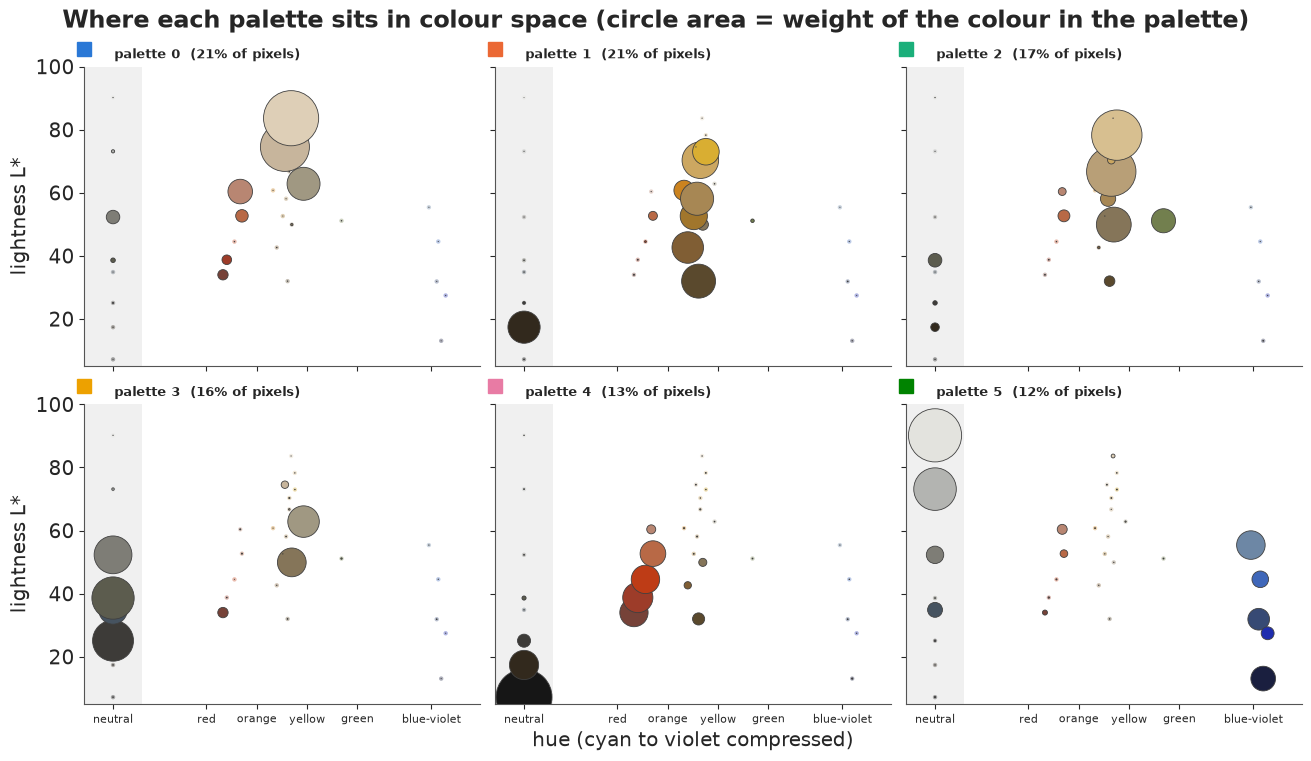

In [23]:
PALETTE_IDS = TOPIC_COLOURS                           # identity colours for palettes 0-5 (same fixed order)
hue_deg = np.degrees(np.arctan2(codebook[:, 2], codebook[:, 1])) % 360
neutral = chroma < 12
# hue axis: keep 0-140 degrees (reds to greens, where most of these colours are) and squeeze the
# nearly empty 140-360 range (cyan to violet) into 70 units
def hue_axis(h):
    return np.where(h <= 140, h, 140 + (h - 140) * 70 / 220)


x_code = np.where(neutral, -40, hue_axis(hue_deg))
lightness = codebook[:, 0]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    ax.scatter(x_code, lightness, s=10, color=swatch, alpha=0.35, lw=0)
    ax.scatter(x_code, lightness, s=phi_col[k] * 4000, color=swatch, edgecolor="0.25", lw=0.6, zorder=3)
    ax.axvspan(-60, -20, color="0.94", zorder=0, lw=0)
    ax.plot([0.0], [1.06], "s", ms=10, color=PALETTE_IDS[k], transform=ax.transAxes, clip_on=False)
    ax.set_title(f"      palette {k}  ({theta_col[:, k].mean():.0%} of pixels)", fontsize=9, loc="left")
    ax.set(xlim=(-60, 215), ylim=(5, 100))
for ax in axes[1]:
    ticks = {"neutral": -40, "red": 25, "orange": 60, "yellow": 95, "green": 130,
             "blue-violet": float(hue_axis(270))}
    ax.set_xticks(list(ticks.values()), list(ticks.keys()), fontsize=8)
axes[1, 1].set_xlabel("hue (cyan to violet compressed)")
for ax in axes[:, 0]:
    ax.set_ylabel("lightness L*")
fig.suptitle("Where each palette sits in colour space (circle area = weight of the colour in the palette)");

The map separates palettes that look alike as strips. Palettes 0 and 2 are both light and warm,
but palette 0 is light neutrals and pinkish beige (paper) while palette 2 adds a mid-tone olive
green and a darker tan. Palette 1 is a column of ochres and golds at every lightness. Palette 3 is
dark neutrals with one slate blue, palette 4 near-black with the saturated reds, and palette 5
the only light palette with real blues - the white paper and printed blues of the silkscreens.

**2. One poster through the model's eyes.** For a poster with mixture $\theta_d$, each pixel's
colour word $w$ belongs to palette $k$ with probability $\propto \theta_{dk}\,\phi_{kw}$. Painting
every pixel with the identity colour of its most probable palette turns the model into a
*segmentation*: which part of the poster is "paper", which is "ink", which is "sky". Below each
poster, a posterior predictive check in colour: its actual colour distribution (all pixels)
against the model's, $\boldsymbol\theta_d^\top\Phi$. Two posters from each era that mix at least
two palettes.

total-variation distance, actual vs model colours: [0.36 0.4  0.2  0.34 0.62 0.39]
all 750 posters: median 0.39, 90th percentile 0.54


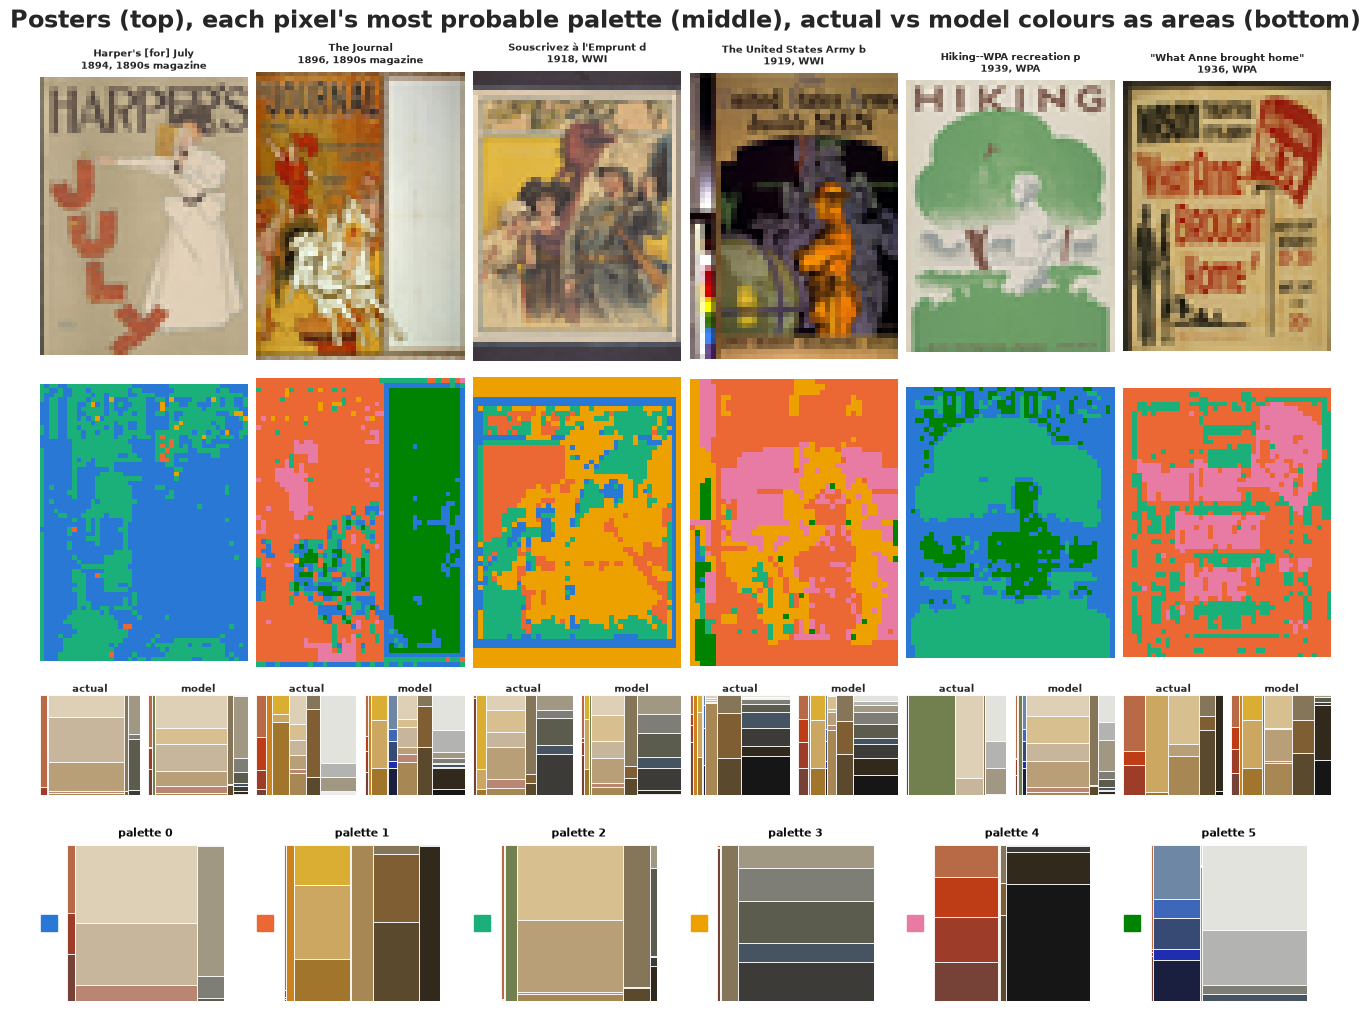

In [24]:
mixing = np.flatnonzero(np.sort(theta_col, 1)[:, -2] > 0.25)
g_show = np.random.default_rng(10)
picks = np.concatenate([g_show.choice(mixing[era_idx[mixing] == e], 2, replace=False) for e in range(3)])
id_rgb = np.array([plt.matplotlib.colors.to_rgb(c) for c in PALETTE_IDS])

fig = plt.figure(figsize=(13, 10))
top_fig, legend_fig = fig.subfigures(2, 1, height_ratios=[8, 1.8])
grid = top_fig.subplots(3, len(picks), height_ratios=[3, 3, 1.3])
tv_dist = []
for c, i in enumerate(picks):
    r0, r1, c0, c1 = boxes[i]
    words_i = poster_words[i]
    resp = theta_col[i][:, None] * phi_col[:, words_i]              # palette x pixel
    seg = id_rgb[resp.argmax(0)].reshape(r1 - r0, c1 - c0, 3)
    grid[0, c].imshow(thumbs[i][r0:r1, c0:c1])
    grid[0, c].set_title(f"{poster_title[i][:24]}\n{poster_year[i]}, {ERAS[era_idx[i]]}", fontsize=7)
    grid[1, c].imshow(seg)
    observed = np.bincount(words_i, minlength=V_COL) / len(words_i)
    fitted = theta_col[i] @ phi_col
    tv_dist.append(0.5 * np.abs(observed - fitted).sum())
    grid[2, c].axis("off")
    for pos, dist, name in [(0.0, observed, "actual"), (0.52, fitted, "model")]:
        ins = grid[2, c].inset_axes([pos, 0, 0.48, 1])
        palette_squares(ins, dist, labels=False)
        ins.set_title(name, fontsize=7, pad=2)
    for ax in grid[:2, c]:
        ax.axis("off")
top_fig.suptitle("Posters (top), each pixel's most probable palette (middle), actual vs model colours as areas (bottom)")
leg = legend_fig.subplots(1, K_COL)
for k, ax in enumerate(leg):
    palette_squares(ax, phi_col[k], labels=False)
    ax.set_title(f"palette {k}", fontsize=8, color=INK)
    ax.plot([-0.12], [0.5], "s", ms=11, color=PALETTE_IDS[k], transform=ax.transAxes, clip_on=False)
print("total-variation distance, actual vs model colours:", np.round(tv_dist, 2))
tv_all = np.array([0.5 * np.abs(np.bincount(w, minlength=V_COL) / len(w) - theta_col[i] @ phi_col).sum()
                   for i, w in enumerate(poster_words)])
print(f"all 750 posters: median {np.median(tv_all):.2f}, 90th percentile {np.percentile(tv_all, 90):.2f}")

The segmentations read like a printer's separation. "Harper's July" (1894) is paper (palette 0)
plus figure and lettering (palette 2). The WPA "Hiking" poster puts its trees in palette 2 (the
olive green) and its ground in palette 0. In the 1919 Army poster the colour-checker strip the
crop missed (left edge) is visible as its own patch - the segmentation doubles as a check on data
preparation.

The colour check below each poster is sobering: six palettes reproduce a poster's colours only
roughly (total-variation distance median 0.39 over all posters; 0 = identical, 1 = no overlap).
The model says *which families* of colour a poster is made of, and spreads each family's share
over all of its colours, so a poster's particular olive or particular red gets diluted. More
palettes would fit better at the cost of readability - the same trade-off as $K$ for the text.

**3. An atlas of the collection.** Each poster's mixture $\theta_d$ is a point on the simplex. To
lay the whole collection out on a page we use the **Hellinger** geometry of mixtures - principal
components of $\sqrt{\theta_d}$ - and place each poster's own thumbnail at its position. The
three panels use the same coordinates, one era each, so the eras can be compared without
colour-coding them, and the arrows show the direction in which each palette's share grows
(labelled with the palette's identity colour).

two components keep 57% of the Hellinger variation


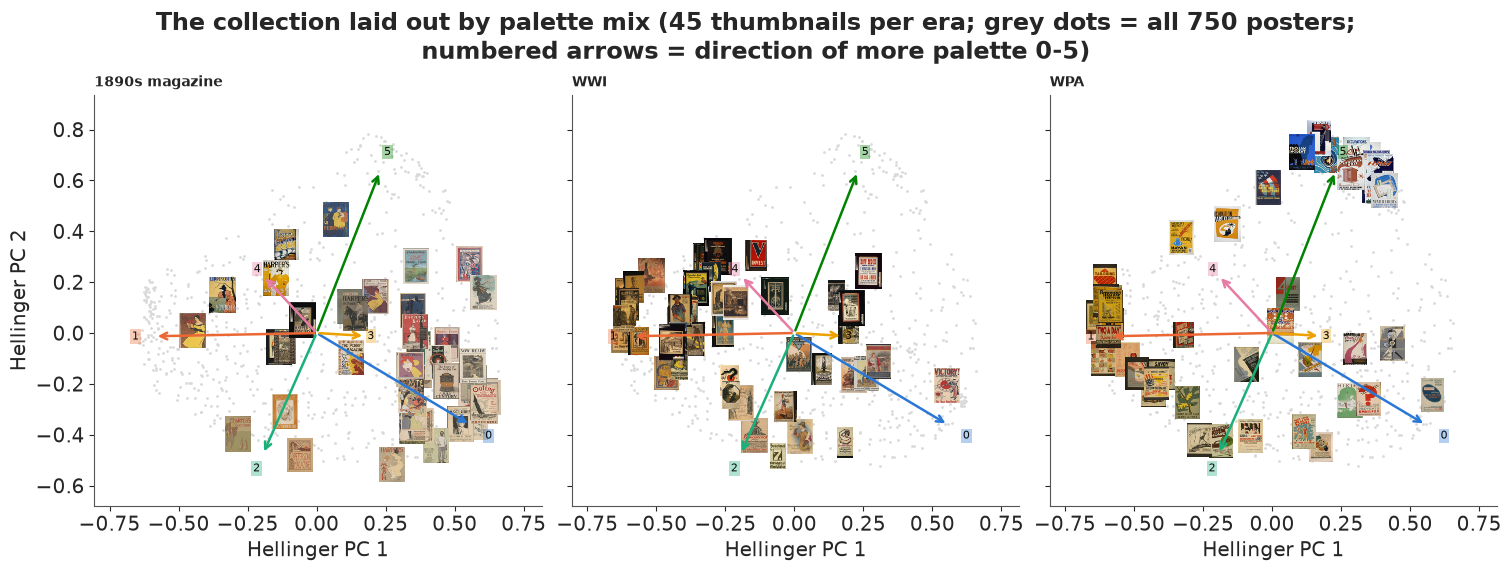

In [25]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

root = np.sqrt(theta_col)
root_c = root - root.mean(0)
_, sv, vt = np.linalg.svd(root_c, full_matrices=False)
atlas = root_c @ vt[:2].T
print(f"two components keep {np.sum(sv[:2]**2) / np.sum(sv**2):.0%} of the Hellinger variation")

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), sharex=True, sharey=True)
g_atlas = np.random.default_rng(11)
for e, ax in enumerate(axes):
    members = np.flatnonzero(era_idx == e)
    ax.scatter(*atlas.T, s=4, color="0.85", lw=0)                               # the whole collection
    for i in g_atlas.choice(members, 45, replace=False):
        r0, r1, c0, c1 = boxes[i]
        ab = AnnotationBbox(OffsetImage(thumbs[i][r0:r1, c0:c1], zoom=0.42), atlas[i], frameon=False)
        ax.add_artist(ab)
    ax.set_title(ERAS[e], fontsize=10, loc="left")
    ax.set_xlabel("Hellinger PC 1")
    for k in range(K_COL):
        tip = vt[:2, k] * 0.9
        ax.annotate("", tip, (0, 0), arrowprops=dict(arrowstyle="->", color=PALETTE_IDS[k], lw=1.8))
        ax.text(*(tip * 1.12), f"{k}", color=INK, fontsize=8, ha="center", va="center",
                bbox=dict(facecolor=PALETTE_IDS[k], alpha=0.35, edgecolor="none", pad=1.2))
axes[0].set_ylabel("Hellinger PC 2")
axes[0].margins(0.12)
fig.suptitle("The collection laid out by palette mix (45 thumbnails per era; grey dots = all 750 posters;\n"
             "numbered arrows = direction of more palette 0-5)");

Two components keep 57% of the variation, enough to see the eras separate: 1890s posters lie
towards palettes 0 and 3 (paper and grey ink), WWI posters towards palettes 1 and 4 (ochre and
black), and the WPA reaches a region the other eras barely enter - up the palette 5 arrow,
where the white-and-blue silkscreens are. The WPA also has a group among the WWI-like ochres:
the era is not one style.

## F. How did palettes change from the 1890s to the WPA? And when was this poster made?

Plain LDA gives every document the same prior mixture. To ask how palettes *depend on* something
about a document - its era, its publisher, its campaign - the prior of $\theta_d$ must depend on
covariates. Two classic designs do this. The **structural topic model** (Roberts et al. 2014,
widely used in the social sciences) replaces the Dirichlet by a **logistic normal** whose mean
depends on covariates; **Dirichlet-multinomial regression** (Mimno & McCallum 2008) keeps the
Dirichlet and lets covariates set its parameters. We try the logistic normal first, because it is
Gaussian underneath and NUTS likes that:

$$\boldsymbol\eta_d \sim \text{Normal}\big(\boldsymbol\mu_{\text{era}(d)},\; \tau^2 I\big),\qquad
\boldsymbol\theta_d = \text{softmax}(\boldsymbol\eta_d),\qquad
\mathbf n_d \sim \text{Multinomial}(200,\; \boldsymbol\theta_d^\top \Phi),$$

with the last palette's $\eta$ fixed at 0 (softmax does not change if a constant is added to every
$\eta$, so one reference palette is needed). $\boldsymbol\mu_{\text{era}}$ is an era's typical
palette mix on the log-odds scale and $\tau$ how much posters of one era differ.

**The palettes $\Phi$ are held fixed** at the posterior mean of the best restart. While preparing
the notebook, fitting them jointly with this model took over 4 minutes with almost every
transition at tree depth 9 or 10 - palettes and mixtures trade off against each other,
$\Theta\Phi = (\Theta A)(A^{-1}\Phi)$ for many matrices $A$ that keep both on the simplex - while
the palette posterior itself is very narrow (its largest sd was printed above).

**Dating posters.** We hide the era of a random 20% of posters and let the model infer it. A
poster without a label gets the era *mixture* as its prior,
$p(\boldsymbol\eta_d) = \sum_{e} \tfrac13\, \text{Normal}(\boldsymbol\eta_d \mid \boldsymbol\mu_e, \tau^2 I)$,
so labelled and unlabelled posters are fitted together (a semi-supervised topic model), and
each hidden poster's era probabilities come out of the posterior. The palettes were learned
without looking at any era label, so nothing leaks.

In [26]:
hide = np.random.default_rng(4).random(len(X_col)) < 0.2
lab_i, unl_i = np.flatnonzero(~hide), np.flatnonzero(hide)
phi_fixed = np.clip(phi_col, 1e-6, None)
phi_fixed /= phi_fixed.sum(1, keepdims=True)
Km1 = K_COL - 1
theta_start = np.clip(theta_col, 1e-3, None)
theta_start /= theta_start.sum(1, keepdims=True)

# starting values from the Gibbs mixtures (log-odds against the reference palette)
eta0 = np.log(theta_start)
eta0 = eta0[:, :Km1] - eta0[:, [Km1]]
mu0 = np.array([eta0[lab_i][era_idx[lab_i] == e].mean(0) for e in range(3)])
coords_era = {"era": ERAS, "free_palette": [f"palette {k}" for k in range(Km1)],
              "palette": [f"palette {k}" for k in range(K_COL)], "labelled": lab_i, "hidden": unl_i}
with pm.Model(coords=coords_era) as ln_model:
    mu = pm.Normal("mu", 0, 3, dims=("era", "free_palette"))
    tau = pm.HalfNormal("tau", 3)
    eta_lab = pm.Normal("eta_lab", mu[era_idx[lab_i]], tau, dims=("labelled", "free_palette"))
    eta_hid = pm.Flat("eta_hid", dims=("hidden", "free_palette"))
    # era mixture prior for the hidden posters, with the era summed out
    comp = (-0.5 * ((eta_hid[:, None, :] - mu[None]) / tau) ** 2
            - pt.log(tau) - 0.5 * np.log(2 * np.pi)).sum(-1)                      # hidden x era
    pm.Potential("era_mixture", pt.logsumexp(comp + np.log(1 / 3), axis=1).sum())

    def softmax_ref(eta):
        return pm.math.softmax(pt.concatenate([eta, pt.zeros((eta.shape[0], 1))], axis=1), axis=1)

    pm.Multinomial("x_lab", n=N_TOK, p=softmax_ref(eta_lab) @ phi_fixed, observed=X_col[lab_i])
    pm.Multinomial("x_hid", n=N_TOK, p=softmax_ref(eta_hid) @ phi_fixed, observed=X_col[hide])
    pm.Deterministic("era_logp", comp, dims=("hidden", "era"))

t0 = time.perf_counter()
idata_ln = pm.sample(model=ln_model, random_seed=RANDOM_SEED, progressbar=False,
                     initvals={"mu": mu0, "tau": 2.0, "eta_lab": eta0[lab_i], "eta_hid": eta0[hide]},
                     var_names=["mu", "tau", "era_logp"])
print(f"sampled in {time.perf_counter() - t0:.0f} s; divergences: {int(idata_ln.sample_stats['diverging'].sum())}; "
      f"tree depth: {np.bincount(idata_ln.sample_stats['depth'].values.ravel())}")
print(az.summary(idata_ln, var_names=["tau"], round_to=3)[["mean", "sd", "r_hat", "ess_bulk"]])
print("max r_hat of mu:", round(float(az.rhat(idata_ln.posterior["mu"]).max()), 3))

sampled in 53 s; divergences: 0; tree depth: [   0    0    0    0    0    0    0 3322  678]
      mean     sd  r_hat  ess_bulk
tau  3.923  0.074  1.001  1214.489
max r_hat of mu: 1.002


The sampler is happy. ($\hat R$ and ESS are fine *within the palette solution we conditioned
on*; the chains started from the Gibbs solution and did not have to find the palettes, so this
says nothing about the other palette sets of part E.) Now the hidden posters. For each posterior
draw, a hidden poster's era probabilities are its normalised mixture components; averaging over
draws gives $P(\text{era} \mid \text{palette})$. We score them three ways: accuracy, the mean
log score (chance: $\log \tfrac13 = -1.10$), and **calibration** - when the model says 80%, is
it right 80% of the time?

In [27]:
truth = era_idx[hide]


def era_probs(idata):
    lp = idata.posterior["era_logp"].values                            # chain, draw, hidden, era
    p = np.exp(lp - lp.max(-1, keepdims=True))
    return (p / p.sum(-1, keepdims=True)).mean((0, 1))


def dating_report(p, name):
    pred, top = p.argmax(1), p.max(1)
    print(f"{name}: accuracy {np.mean(pred == truth):.2f} (chance 0.33), mean log score "
          f"{np.mean(np.log(p[np.arange(len(truth)), truth])):.3f} (chance {np.log(1 / 3):.3f})")
    for lo_, hi_ in [(0.33, 0.6), (0.6, 0.8), (0.8, 1.01)]:
        sel = (top >= lo_) & (top < hi_)
        if sel.any():
            print(f"   stated top probability {lo_:.2f}-{min(hi_, 1):.2f}: {sel.sum():3d} posters, "
                  f"mean stated {top[sel].mean():.2f}, actually correct {np.mean(pred[sel] == truth[sel]):.2f}")


p_ln = era_probs(idata_ln)
dating_report(p_ln, "logistic normal")

logistic normal: accuracy 0.55 (chance 0.33), mean log score -1.128 (chance -1.099)
   stated top probability 0.33-0.60:  44 posters, mean stated 0.50, actually correct 0.45
   stated top probability 0.60-0.80:  50 posters, mean stated 0.71, actually correct 0.58
   stated top probability 0.80-1.00:  48 posters, mean stated 0.89, actually correct 0.60


Better than chance at picking the era (0.55 against 0.33) - and yet the log score is *worse
than guessing* (-1.13 against -1.10). The model is **overconfident**: when it says about 0.89,
it is right 60% of the time. A classifier that is right more often than chance but loses to "I
don't know" on log score is making some confident mistakes that cost a lot.

The cause is the logistic normal's shape. A palette that is (almost) absent from a poster has a
very negative log-odds $\eta_{dk}$, and the only thing holding it is the Gaussian prior, which is
**quadratic** in $\eta$. The large $\tau$ (about 3.9) is the model stretching to cover these far
tails, and the eras' Gaussians disagree steeply out there: small differences in how
absent a palette is become big differences in era probability.

The Dirichlet does not have this problem. Its log-density is **linear** in the log-shares,
$\sum_k (\alpha_k - 1)\log\theta_k$, so a palette that is absent from a poster costs a bounded,
gentle amount, and a small $\alpha_k$ says "absent is normal". So: **Dirichlet-multinomial
regression**, with one Dirichlet per era,

$$\boldsymbol\theta_d \sim \text{Dirichlet}(\boldsymbol\alpha_{\text{era}(d)}), \qquad
\log\alpha_{ek} \sim \text{Normal}(\log 0.5,\; 1.5).$$

Its mean $\boldsymbol\alpha_e / \sum_k \alpha_{ek}$ is the era's average palette mix, and its
total $\sum_k \alpha_{ek}$ how alike the era's posters are (small = each poster uses few palettes).

How to sample it matters. `pm.Dirichlet` works (while preparing: 295 s, almost every transition
at the maximum tree depth, and similar answers). Faster is the textbook construction: if
$g_k \sim \text{Gamma}(\alpha_k, 1)$ independently, then $\mathbf g / \sum_k g_k$ is
$\text{Dirichlet}(\boldsymbol\alpha)$. Sample $u_k = \log g_k$, whose density is
$\exp(\alpha_k u_k - e^{u_k}) / \Gamma(\alpha_k)$, and set $\boldsymbol\theta = \text{softmax}(\mathbf u)$.
The scale $\sum_k g_k$ is an extra direction the data never see, but its prior keeps it in
place. For a hidden poster the prior of $\mathbf u$ is the equal-weight mixture over eras of
these densities, which is exact.

In [28]:
with pm.Model(coords=coords_era) as dmr_model:
    log_alpha = pm.Normal("log_alpha", np.log(0.5), 1.5, dims=("era", "palette"))
    alpha = pt.exp(log_alpha)
    u_lab = pm.Flat("u_lab", dims=("labelled", "palette"))
    a_lab = alpha[era_idx[lab_i]]
    pm.Potential("gamma_lab", (a_lab * u_lab - pt.exp(u_lab) - pt.gammaln(a_lab)).sum())
    u_hid = pm.Flat("u_hid", dims=("hidden", "palette"))
    comp = (alpha[None] * u_hid[:, None, :] - pt.exp(u_hid)[:, None, :] - pt.gammaln(alpha)[None]).sum(-1)
    pm.Potential("era_mixture", pt.logsumexp(comp + np.log(1 / 3), axis=1).sum())
    pm.Multinomial("x_lab", n=N_TOK, p=pm.math.softmax(u_lab, axis=1) @ phi_fixed, observed=X_col[lab_i])
    pm.Multinomial("x_hid", n=N_TOK, p=pm.math.softmax(u_hid, axis=1) @ phi_fixed, observed=X_col[hide])
    pm.Deterministic("era_logp", comp, dims=("hidden", "era"))

t0 = time.perf_counter()
idata_dmr = pm.sample(model=dmr_model, random_seed=RANDOM_SEED, progressbar=False,
                      initvals={"log_alpha": np.full((3, K_COL), np.log(0.5)),
                                "u_lab": np.log(theta_start[lab_i]), "u_hid": np.log(theta_start[hide])},
                      var_names=["log_alpha", "era_logp"])
print(f"sampled in {time.perf_counter() - t0:.0f} s; divergences: {int(idata_dmr.sample_stats['diverging'].sum())}; "
      f"tree depth: {np.bincount(idata_dmr.sample_stats['depth'].values.ravel())}")
print("max r_hat of log alpha:", round(float(az.rhat(idata_dmr.posterior["log_alpha"]).max()), 3),
      "| min bulk ESS:", int(az.ess(idata_dmr.posterior["log_alpha"]).min()))
p_dmr = era_probs(idata_dmr)
dating_report(p_ln, "logistic normal")
dating_report(p_dmr, "Dirichlet     ")

sampled in 151 s; divergences: 0; tree depth: [   0    0    0    0    0    0    0    0 4000]
max r_hat of log alpha: 1.015 | min bulk ESS: 569
logistic normal: accuracy 0.55 (chance 0.33), mean log score -1.128 (chance -1.099)
   stated top probability 0.33-0.60:  44 posters, mean stated 0.50, actually correct 0.45
   stated top probability 0.60-0.80:  50 posters, mean stated 0.71, actually correct 0.58
   stated top probability 0.80-1.00:  48 posters, mean stated 0.89, actually correct 0.60
Dirichlet     : accuracy 0.48 (chance 0.33), mean log score -1.022 (chance -1.099)
   stated top probability 0.33-0.60:  67 posters, mean stated 0.52, actually correct 0.46
   stated top probability 0.60-0.80:  50 posters, mean stated 0.71, actually correct 0.40
   stated top probability 0.80-1.00:  25 posters, mean stated 0.85, actually correct 0.68


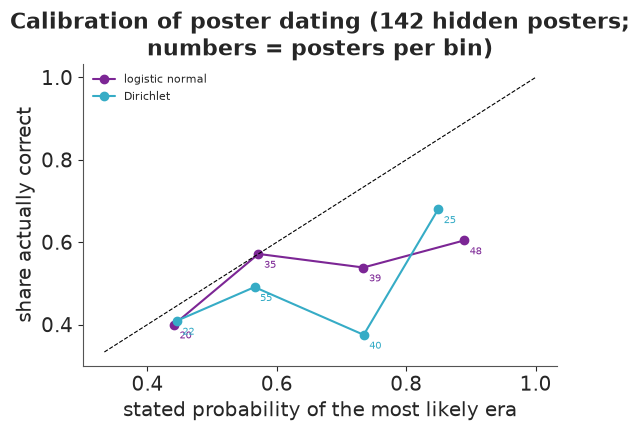

In [29]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
bins = np.array([1 / 3, 0.5, 0.65, 0.8, 1.0001])
for p, name, col in [(p_ln, "logistic normal", "C3"), (p_dmr, "Dirichlet", "C0")]:
    top, correct = p.max(1), p.argmax(1) == truth
    b = np.digitize(top, bins) - 1
    xs = [top[b == j].mean() for j in range(len(bins) - 1) if np.any(b == j)]
    ys = [correct[b == j].mean() for j in range(len(bins) - 1) if np.any(b == j)]
    ns = [np.sum(b == j) for j in range(len(bins) - 1) if np.any(b == j)]
    ax.plot(xs, ys, "o-", color=col, label=name)
    for x_, y_, n_ in zip(xs, ys, ns):
        ax.annotate(str(n_), (x_, y_), textcoords="offset points", xytext=(4, -10), fontsize=7, color=col)
ax.plot([1 / 3, 1], [1 / 3, 1], color="k", lw=0.8, ls="--")
ax.set(xlabel="stated probability of the most likely era", ylabel="share actually correct",
       title="Calibration of poster dating (142 hidden posters;\nnumbers = posters per bin)")
ax.legend(fontsize=8);

The Dirichlet model samples cleanly (zero divergences, $\hat R$ about 1.01) in about two and a
half minutes, at tree depth 8. For dating it is the better *probabilistic* model: its log score,
-1.02, beats both guessing (-1.10) and the logistic normal (-1.13), and its most confident
datings (about 25 posters stated at about 0.85) are right about 70% of the time. It is not simply
better: its accuracy is lower (0.48 against 0.55), and posters it gives 0.6-0.8 are right only
about 40% of the time.
With 142 posters these bins are noisy, but the picture is clear enough: **colour alone dates a
poster only roughly**, and the prior shape decides how honest the model is about that. Both
models are overconfident - part G suggests one reason.

What did each era look like? From the Dirichlet model, an era's average palette mix is
$\boldsymbol\alpha_e / \sum_k \alpha_{ek}$, for every posterior draw.

Dirichlet total (small = each poster uses few palettes), posterior mean: {'1890s magazine': np.float64(1.49), 'WWI': np.float64(1.81), 'WPA': np.float64(1.08)}


Text(0.5, 1.0, 'Era composition: each segment is one palette, drawn in its own colours\n(square = palette identity; label = palette: share)')

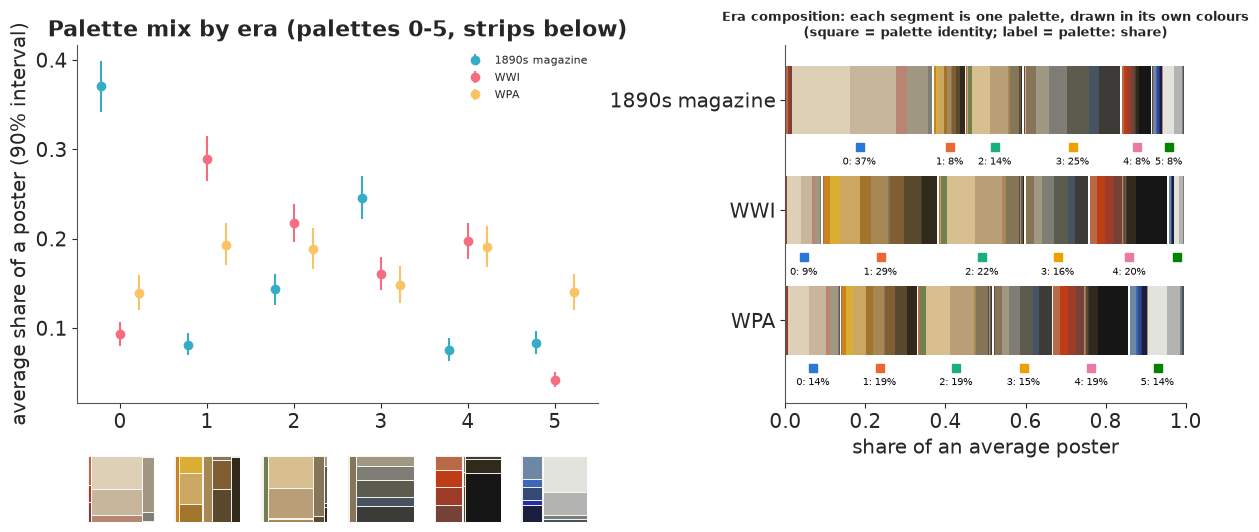

In [30]:
alpha_draws = np.exp(az.extract(idata_dmr, var_names=["log_alpha"]).transpose("sample", "era", "palette").values)
share = alpha_draws / alpha_draws.sum(-1, keepdims=True)                 # draw, era, palette
conc = alpha_draws.sum(-1)
print("Dirichlet total (small = each poster uses few palettes), posterior mean:",
      dict(zip(ERAS, conc.mean(0).round(2))))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), width_ratios=[1.3, 1])
for e in range(3):
    lo, hi = np.quantile(share[:, e], [0.05, 0.95], axis=0)
    mid = share[:, e].mean(0)
    axes[0].errorbar(np.arange(K_COL) + (e - 1) * 0.22, mid, yerr=[mid - lo, hi - mid], fmt="o",
                     color=f"C{e}", label=ERAS[e])
axes[0].set_xticks(range(K_COL), [str(k) for k in range(K_COL)])
axes[0].set(ylabel="average share of a poster (90% interval)", title="Palette mix by era (palettes 0-5, strips below)")
axes[0].legend(fontsize=8)
for k in range(K_COL):                                              # palette squares under the axis
    ins = axes[0].inset_axes([k / K_COL + 0.02, -0.34, 1 / K_COL - 0.04, 0.2], transform=axes[0].transAxes)
    palette_squares(ins, phi_col[k], labels=False)
mean_share = share.mean(0)                                          # era x palette
for e in range(3):                                                  # 100% bars, segments filled with the palette
    left = 0.0
    for k in range(K_COL):
        w_k = mean_share[e, k]
        o = display_order
        widths = phi_col[k][o] * (w_k - 0.004)                          # 0.004 leaves a white gap
        axes[1].barh(e, widths, left=left + np.r_[0, np.cumsum(widths)[:-1]], height=0.62,
                     color=swatch[o], lw=0)
        axes[1].plot([left + w_k / 2], [e + 0.43], "s", ms=6, color=PALETTE_IDS[k])
        if w_k > 0.06:
            axes[1].text(left + w_k / 2, e + 0.52, f"{k}: {w_k:.0%}", ha="center", va="top", fontsize=7, color=INK)
        left += w_k
axes[1].set(xlim=(0, 1), ylim=(2.75, -0.5), xlabel="share of an average poster")
axes[1].set_yticks(range(3), ERAS)
axes[1].grid(False)
axes[1].set_title("Era composition: each segment is one palette, drawn in its own colours\n"
                  "(square = palette identity; label = palette: share)", fontsize=9)

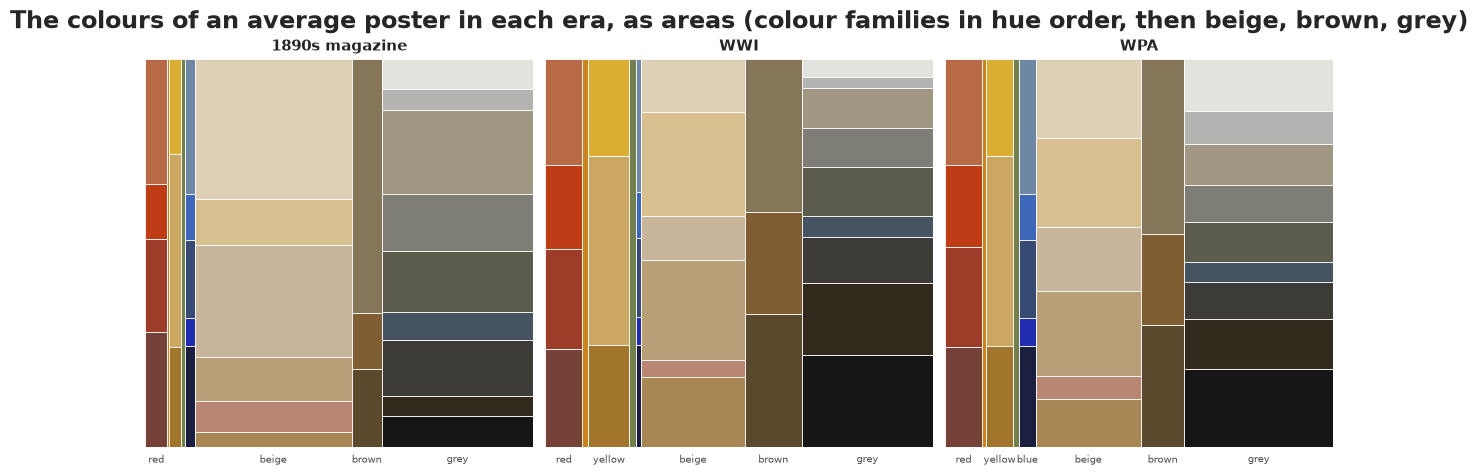

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))
for e, ax in enumerate(axes):
    palette_squares(ax, mean_share[e] @ phi_col, min_label=0.04)
    ax.set_title(ERAS[e], fontsize=11)
fig.suptitle("The colours of an average poster in each era, as areas (colour families in hue order, then beige, brown, grey)");

In [32]:
pairs = [(0, 1), (1, 2), (0, 2)]
diff = pd.DataFrame({f"{ERAS[b]} - {ERAS[a]}": (share[:, b] - share[:, a]).mean(0) for a, b in pairs},
                    index=[f"palette {k}" for k in range(K_COL)])
prob = pd.DataFrame({f"P({ERAS[b]} > {ERAS[a]})": (share[:, b] > share[:, a]).mean(0) for a, b in pairs},
                    index=diff.index)
print(pd.concat([diff.round(3), prob.round(3)], axis=1))

           WWI - 1890s magazine  WPA - WWI  WPA - 1890s magazine  P(WWI > 1890s magazine)  P(WPA > WWI)  P(WPA > 1890s magazine)
palette 0                -0.277      0.046                -0.231                      0.0         1.000                    0.000
palette 1                 0.208     -0.097                 0.112                      1.0         0.000                    1.000
palette 2                 0.074     -0.028                 0.046                      1.0         0.072                    0.995
palette 3                -0.085     -0.012                -0.097                      0.0         0.241                    0.000
palette 4                 0.121     -0.007                 0.114                      1.0         0.360                    1.000
palette 5                -0.042      0.098                 0.057                      0.0         1.000                    1.000


The history of the three eras is readable in the palette shares (left: each palette's share with
its interval; right: the same shares as one bar per era, each segment painted with its palette,
so the overall look of an era is visible at a glance; and the three squares, the colours of an
average poster of each era):

* **1890s magazine posters** are paper and ink: palette 0 (cream paper) makes up about 37% of an
  average poster and the greys of palette 3 another 25%. Their Dirichlet total (about 1.5)
  says a typical poster uses one or two palettes.
* **WWI posters** swap the paper for full-colour lithography on dark grounds: the ochre-brown
  palette 1 (about 29%, more than three times the 1890s share) and black-red palette 4 (about
  20%) take over, and white-blue palette 5 all but disappears.
* **WPA posters** keep black-red palette 4 at the WWI level, use less ochre-brown (palette 1
  falls from about 29% to 19%), and bring back light grounds: white-blue palette 5 rises from
  about 4% to 14% (P > 0.99), and cream paper rises a little (silkscreens on light stock).

Every pairwise change marked with P = 0 or 1 in the table is certain *given this palette
solution*; the restart table of part E is the reminder that palettes 1 and 3 are not the only
way to cut the dark colours.

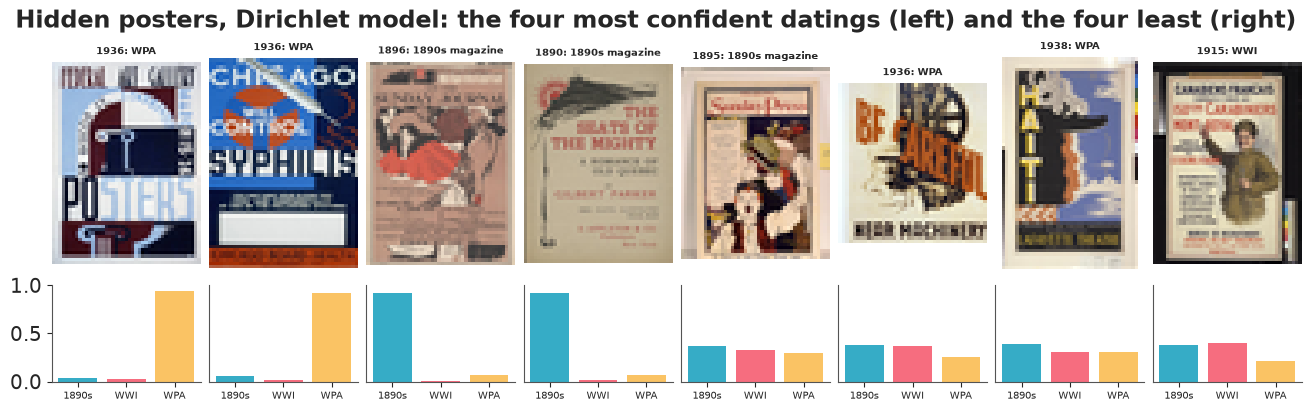

In [33]:
top_dmr = p_dmr.max(1)
show = np.r_[np.argsort(-top_dmr)[:4], np.argsort(top_dmr)[:4]]
fig, axes = plt.subplots(2, 8, figsize=(13, 4), height_ratios=[2.2, 1])
for c, j in enumerate(show):
    i = unl_i[j]
    r0, r1, c0, c1 = boxes[i]
    axes[0, c].imshow(thumbs[i][r0:r1, c0:c1])
    axes[0, c].axis("off")
    axes[0, c].set_title(f"{poster_year[i]}: {ERAS[era_idx[i]]}", fontsize=7)
    axes[1, c].bar(range(3), p_dmr[j], color=["C0", "C1", "C2"])
    axes[1, c].set(ylim=(0, 1), xticks=range(3), yticks=[0, 0.5, 1] if c == 0 else [])
    axes[1, c].set_xticklabels(["1890s", "WWI", "WPA"], fontsize=7)
fig.suptitle("Hidden posters, Dirichlet model: the four most confident datings (left) and the four least (right)");

The easy cases sit at the extremes of the palette space: white-and-blue WPA silkscreens and
cream-paper 1890s posters. The hard ones borrow another era's colours - a colourful 1890s
lithograph, WPA and WWI posters on light cream paper. Nothing in a palette alone can date those;
subject matter, typography and text would.

## G. How much is a picture worth?

Every result above used 200 tokens per poster. The multinomial treats them as independent
draws, so its certainty grows like $\sqrt N$: with all of a crop's ~2,600 pixels, every
interval above would shrink by a factor of about 3.6. Is that real information or pseudo-
replication?

A direct check: split each cropped poster into its **top and bottom halves** and compare their
colour counts. If pixels were independent draws from one colour distribution, the halves would
differ only by multinomial noise, and the chi-square statistic for "same distribution" would be
about its degrees of freedom. The ratio statistic / df is an **overdispersion factor**: the
number of pixels that behave like one independent token. Dividing a poster's pixel count by it
gives an effective number of tokens.

(Posters are designed, and a top half - a title - can legitimately differ from a bottom half -
a picture. That makes the check conservative: it can only overstate how much pixels disagree,
and so understate the effective number of tokens a little, never overstate it.)

pixels per cropped poster: median 2640
overdispersion (chi2 / df, 1 = independent pixels): median 20, quartiles 12-33
effective independent tokens per poster: median 120, quartiles 72-196
odd vs even columns (neighbouring pixels): median chi2 / df 1.7


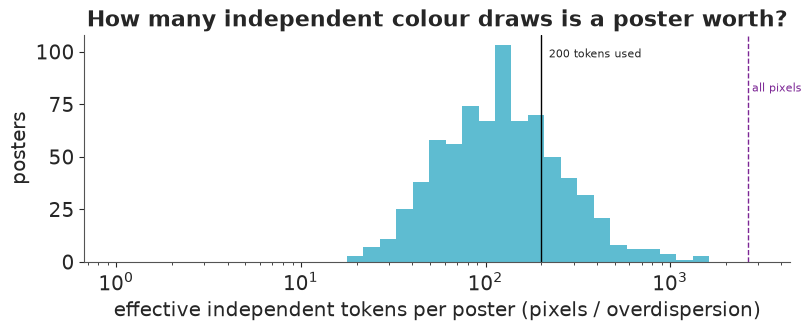

In [34]:
def overdispersion(words, V):
    half = len(words) // 2
    a, b = np.bincount(words[:half], minlength=V), np.bincount(words[half:2 * half], minlength=V)
    keep_w = (a + b) > 0
    a, b = a[keep_w], b[keep_w]
    expected = (a + b) / 2
    chi2 = np.sum((a - expected) ** 2 / expected) * 2
    return chi2 / max(keep_w.sum() - 1, 1)


# words were computed row by row (row-major), so the first half of the pixels is the top half
disp = np.array([overdispersion(w, V_COL) for w in poster_words])
n_pix = np.array([len(w) for w in poster_words])
n_eff = n_pix / np.maximum(disp, 1)
print(f"pixels per cropped poster: median {np.median(n_pix):.0f}")
print(f"overdispersion (chi2 / df, 1 = independent pixels): median {np.median(disp):.0f}, "
      f"quartiles {np.percentile(disp, 25):.0f}-{np.percentile(disp, 75):.0f}")
print(f"effective independent tokens per poster: median {np.median(n_eff):.0f}, "
      f"quartiles {np.percentile(n_eff, 25):.0f}-{np.percentile(n_eff, 75):.0f}")

# a within-half check with no design difference: odd vs even columns of the same rows
disp_cols = []
for t, (r0, r1, c0, c1), w in zip(thumbs, boxes, poster_words):
    grid = w.reshape(r1 - r0, c1 - c0)
    disp_cols.append(overdispersion(np.r_[grid[:, ::2].ravel(), grid[:, 1::2].ravel()[: grid[:, ::2].size]], V_COL))
print(f"odd vs even columns (neighbouring pixels): median chi2 / df {np.median(disp_cols):.1f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.clip(n_eff, 1, 3000), bins=np.geomspace(1, 3000, 40), color="C0", alpha=0.8)
ax.axvline(N_TOK, color="k", lw=1)
ax.text(N_TOK * 1.1, ax.get_ylim()[1] * 0.9, f"{N_TOK} tokens used", fontsize=8)
ax.axvline(np.median(n_pix), color="C3", lw=1, ls="--")
ax.text(np.median(n_pix) * 1.05, ax.get_ylim()[1] * 0.75, "all pixels", fontsize=8, color="C3")
ax.set(xscale="log", xlabel="effective independent tokens per poster (pixels / overdispersion)",
       ylabel="posters", title="How many independent colour draws is a poster worth?");

Top and bottom halves of the same poster disagree about 20 times more than independent pixels
would (median chi-square / df; quartiles 12-33). Dividing each poster's ~2,600 pixels by that factor gives a
median of about **120 effective independent colour draws** per poster. Neighbouring columns,
on the other hand, agree almost perfectly (chi-square / df 1.7): the pixels are near-copies of
their neighbours, so adding them adds almost nothing.

So the 200 tokens we used overstate a typical poster's evidence by a factor of about 1.7 (so
intervals about 1.3 times too narrow), and using every pixel would have overstated it about
20-fold (intervals about 4.7 times too narrow). This is one plausible contributor to the
overconfident dating of part F (exercise 1 tests it). Two remedies:

* choose the number of tokens per document from a check like this one (here about 100-120), or
* keep all pixels and **temper** the likelihood by $N_\text{eff}/N$ (a "power likelihood"), which
  has the same effect on uncertainty.

The same question arises whenever a "document" is built from correlated measurements: repeated
words within one text, sessions from one user, reads from one sequencing library.

## Summary

* **LDA is a model of any count table.** Documents x features, each document a mixture of a few
  feature distributions: words in stories, colours in posters - and baskets, genomes, microbiomes
  and sessions in the same way.
* **PyMC can fit it** once the token topics are summed out, but label switching makes raw
  $\hat R$ meaningless (1.75 with zero divergences on simulated data; 1.008 after aligning chains
  with the Hungarian algorithm). On a sparse 650-word vocabulary NUTS struggled badly; a
  collapsed Gibbs sampler in Numba fits 4,468 documents in seconds.
* **Stability is part of the answer.** Some headline topics came back in every chain, others did
  not, while fake data from LDA itself were recovered almost exactly: instability is the mark of
  a model that fits real text only approximately. Report topics with their stability.
* **Choose $K$ for the purpose.** Held-out word prediction kept improving up to 80 topics (it
  rewards memorising stories); predicting click-through stopped improving at about 4.
* **Uncertain regressors: plug in the posterior mean.** Pooling regressions over posterior draws
  of the topic mixtures shrank every click-through effect by about a quarter, in a simulation with
  known effects as on the real data; the posterior-mean plug-in was unbiased. Multiple imputation
  needs an imputation model that sees the outcome.
* **Pictures become documents** with a CIELab colour vocabulary, once the scanner's contribution
  (backing and colour strips) is removed. Six palettes separate paper, ink, lithography and
  silkscreen without any labels.
* **Covariates on the mixtures** describe how palettes changed across eras and let the model date
  unlabelled posters. The prior's shape matters: a logistic normal was overconfident (log score
  worse than guessing); a Dirichlet, sampled as normalised log-Gammas, was better but still
  overconfident. Colour alone dates posters only roughly.
* **Show topics where they live.** Relevance-ranked words, a stability-aware topic map, words
  highlighted inside documents and prevalence over time explain word topics far better than a
  top-10 list; palettes read best on a lightness-hue map, as pixel segmentations of real posters
  (with a check of how well the model reproduces each poster's colours - roughly, here), in an
  atlas of thumbnails, and as era bars painted in their own colours.
* **Pixels are not independent tokens**: a poster is worth about 120 independent colour draws,
  not 2,600. How many tokens a document contributes is a modelling decision with consequences
  for every interval.

## Try it yourself

1. **Temper the posters.** Refit the Dirichlet era model with 100 tokens per poster (or all pixels
   with the log-likelihood multiplied by $N_\text{eff}/N$ per poster, via `pm.Potential`). Does the
   calibration of the dating improve? Does the log score?
2. **Supervised LDA.** Put the click-through regression inside the text model so that clicks and
   words inform the mixtures together: add the Normal likelihood of part C to the Gibbs sampler's
   full conditional for each token's topic (Blei & McAuliffe 2007 derive it). Do topics change?
   Do the effects move away from the plug-in estimates?
3. **Another bag of features.** Use the same code on a different count table: word counts per
   speech in a collection of political speeches, products per order in a public retail dataset,
   or the `bci_trees` species counts per plot used in E30 (plots as documents, species as words:
   the topics are plant communities). Which parts of this notebook's checks carry over?